# Classical shadows — tomography without the $4^N$ wall

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 8 — Quantum information protocols*

## 1. Introduction and motivation

The previous notebook, [23 — quantum state tomography](../ch08_quantum_information_protocols/23_quantum_state_tomography.ipynb),
ended at a wall. Full tomography needs $3^N$ measurement settings to pin down the $4^N-1$ real parameters of a density matrix,
and every one of those parameters must be measured to a useful accuracy. Beyond $N\approx10$ the experiment alone is out of
reach, and the reconstruction is worse.

But look again at what a laboratory actually *wants*. Almost never all $4^N$ numbers. It wants an energy
$\langle H\rangle$, a handful of correlators $\langle Z_iZ_j\rangle$, the fidelity with one target state, an entanglement
witness, a few subsystem entropies. That is a list of $K$ numbers with $K$ in the tens or hundreds — not $4^N$.
**Why should predicting $K$ numbers cost as much as reconstructing the whole state?**

It does not. In 2018 Scott Aaronson formulated the *shadow tomography* problem — predict $K$ observables of an unknown state
using a number of copies growing only **polylogarithmically** in $K$ — and proved it is possible in principle.
In 2020 Huang, Kueng and Preskill turned the idea into a concrete measurement protocol:

> Measure every qubit along a **randomly chosen** axis. Write down which axes you chose and which bits came out.
> Repeat $M$ times. That list of $2NM$ integers — the **classical shadow** — is enough to predict, after the fact,
> the expectation value of any observable you later become interested in.

No setting list is decided in advance; nothing is reconstructed; the state is never stored. Each measurement record is
converted into a *classical snapshot* $\hat\rho_m$ — a little $2^N\times2^N$ object with the property that its **average over
the randomness is exactly $\rho$**. Any expectation value is then a plain sample mean, with a variance we can compute.

**What we will do.**

1. **The measurement channel.** The random measurement defines a linear map $\mathcal M(\rho)=\mathbb E[\,U^\dagger\vert b\rangle\langle b\vert U\,]$.
   We derive it for random single-qubit Pauli bases — it is the depolarising channel with parameter $1/3$ — invert it exactly,
   $\mathcal M^{-1}(A)=3A-\mathrm{Tr}(A)\mathbb 1$, and check the inverse numerically (Sections 3–4).
2. **The estimator.** One snapshot gives an unbiased estimate of every observable at once. For a Pauli string of weight $k$
   the estimator collapses to a product of signs, and we prove (and measure) that its variance is exactly $3^k-\langle P\rangle^2$ —
   **independent of $N$** (Sections 5–6).
3. **How many snapshots.** The **shadow norm**, the $\log K$ sample complexity, and **median of means** — derived from
   Chebyshev plus Hoeffding, implemented, and then measured against the plain sample mean, which it does *not* beat at the
   budgets this notebook can afford (Section 6).
4. **One data set, many observables.** From a single set of $M$ snapshots of an eight-qubit critical Ising ground state we predict
   $\langle X_1\rangle$, $\langle Z_1Z_2\rangle$, $\langle X_1X_2X_3\rangle$, **all** nearest-neighbour correlators and the energy,
   with bootstrap error bars, and watch everything converge as $M^{-1/2}$ (Sections 7–8).
5. **Other random ensembles.** The 24-element single-qubit Clifford group gives *exactly the same* channel as random Pauli bases
   (we prove it and check it to machine precision). Entangling **global** Clifford circuits give a completely different channel,
   $\mathcal M^{-1}(A)=(2^N+1)A-\mathrm{Tr}(A)\mathbb 1$, which we derive from the 2-design property and verify numerically for the
   ensemble we actually sample. The two are complementary: local shadows are cheap for local observables and useless for fidelity;
   global shadows are the exact opposite (Sections 9–10).
6. **Comparison and scaling.** Reconstruct $\rho$ for $N=3$ and compare with the linear-inversion and projected estimators of
   notebook 23 **at an equal total shot budget**; then push local observables to $N=14$ and watch the cost *not* grow (Sections 11–12).

### What you will learn

*Physics*

* what a randomised measurement is, and why averaging over random bases produces a depolarising channel;
* the difference between *reconstructing a state* and *predicting observables*, and why only the second is scalable;
* why the accuracy of a $k$-local observable does not depend on the system size, while the accuracy of a fidelity does;
* unitary $2$- and $3$-designs, and what the Clifford group has to do with all of this.

*Numerical methods*

* inverting a linear map on operators (a superoperator) and checking it by building its matrix;
* unbiased estimators, their variance, the shadow norm, and Chebyshev/Hoeffding sample-complexity bounds;
* median of means as a robust estimator for heavy-tailed random variables;
* the bootstrap applied to a data set of snapshots;
* Monte-Carlo verification of a moment condition (here: a 2-design property) with honest error bars.

*Implementation practice*

* `vmap` over snapshots with one PRNG key each, and **chunking** a `vmap` so that it does not exhaust memory;
* turning "a product of single-qubit $2\times2$ matrices" into a gather plus a chain of `apply_gate` einsums;
* one einsum for a whole superoperator;
* estimating hundreds of observables from one integer array without ever building a $2^N\times2^N$ matrix.

### Prerequisites
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, explicit PRNG keys;
* [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb): index notation as executable code;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density matrices, the depolarising channel, fidelity, trace distance;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): Born rule, basis rotations, sampling bit strings;
* [10 — random unitaries and random circuits](../ch04_digital_quantum_circuits/10_random_unitaries_and_random_circuits.ipynb):
  Haar-random unitaries, random circuits;
* **[23 — quantum state tomography](../ch08_quantum_information_protocols/23_quantum_state_tomography.ipynb)**: this notebook is its
  direct continuation. We reuse its notation without re-deriving it — the Pauli vector $r_P=\langle P\rangle$, the expansion
  $\rho=2^{-N}\sum_Pr_PP$, measurement settings, shots, and its linear-inversion estimator, which we use here as the reference
  to beat (or not) at an equal shot budget.

**Conventions.** Qubit $q$ = tensor axis $q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$; an outcome bit $s_q\in\{0,1\}$ means
the eigenvalue $(-1)^{s_q}$. In notebook 23 the letter $M$ was the number of shots *per setting*; **here $M$ is the number of
snapshots**, i.e. the total number of runs of the machine. When we compare the two methods we always compare the *total* number
of runs, which we call $T$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

From the engine we take the einsum gate application, the state constructors, the matrix-free Pauli expectation values, the
transverse-field Ising Hamiltonian with its Lanczos ground state, and the three shadow primitives that this notebook is about:
`collect_pauli_shadows` (the randomised-measurement data generator), `shadow_estimate_pauli` (the single-snapshot Pauli estimator)
and `shadow_snapshot_dm` (the dense single-snapshot state estimate). Everything else is built below from scratch.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def trace_distance(rho, sigma):
    """D = (1/2)||rho - sigma||_1 = (1/2) sum_i |eigenvalue_i(rho - sigma)|  (Hermitian difference)."""
    return 0.5 * jnp.sum(jnp.abs(jnp.linalg.eigvalsh(rho - sigma)))


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U

# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]

def single_qubit_cliffords():
    """The 24 single-qubit Clifford gates (modulo global phase), generated by closing {H, S} under
    multiplication (breadth-first search; a canonical phase makes matrices comparable)."""
    found = [np.eye(2, dtype=complex)]
    gens = [np.asarray(H), np.asarray(S)]

    def canon(U):
        i = np.flatnonzero(np.abs(U.reshape(-1)) > 1e-9)[0]
        return U * np.exp(-1j * np.angle(U.reshape(-1)[i]))

    frontier = [found[0]]
    while frontier:
        nxt = []
        for U in frontier:
            for g in gens:
                V = canon(g @ U)
                if not any(np.allclose(V, W) for W in found):
                    found.append(V)
                    nxt.append(V)
        frontier = nxt
    return jnp.asarray(np.stack(found), dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 13. Classical shadows (random Pauli measurements)
# ----------------------------------------------------------------------------
def collect_pauli_shadows(key, psi, n_shadows):
    """Randomised-measurement data set (Huang, Kueng, Preskill 2020).
    Each snapshot: draw a basis b_q in {X,Y,Z} for every qubit, rotate, measure all qubits once.
    Returns (bases, bits), int arrays of shape (n_shadows, N); basis code 0=X, 1=Y, 2=Z.
    JAX: one snapshot is a pure function of its key  ->  `vmap` over keys gives all snapshots in parallel;
         `rots[bases[q]]` selects the rotation with a traced index (gather), so no Python branching."""
    N = psi.ndim
    rots = jnp.stack([_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]])

    def one(k):
        kb, ks = jax.random.split(k)
        bases = jax.random.randint(kb, (N,), 0, 3)
        phi = psi
        for q in range(N):
            phi = apply_gate(phi, rots[bases[q]], [q])
        logp = jnp.log(jnp.clip(jnp.abs(phi.reshape(-1)) ** 2, 1e-300, None))
        idx = jax.random.categorical(ks, logp)
        bits = (idx >> jnp.arange(N - 1, -1, -1)) & 1
        return bases, bits

    return jax.vmap(one)(jax.random.split(key, n_shadows))

def shadow_estimate_pauli(bases, bits, ops):
    """Estimate <P> of a Pauli string `ops` = {qubit: 'X'|'Y'|'Z'} from Pauli shadows.
        single-snapshot estimator   o = prod_{q in supp(P)}  3 * [b_q == P_q] * (-1)^{bit_q}
    (the factor 3 per qubit inverts the measurement channel; a snapshot contributes only if all its bases
    match on the support -- probability 3^{-k} -- hence variance ~ 3^k for weight-k strings).
    Returns (mean, standard error)."""
    code = {"X": 0, "Y": 1, "Z": 2}
    val = jnp.ones(bases.shape[0])
    for q, p in ops.items():
        val = val * 3.0 * (bases[:, q] == code[p]) * (1 - 2 * bits[:, q])
    return jnp.mean(val), jnp.std(val) / jnp.sqrt(val.shape[0])

def shadow_snapshot_dm(bases_row, bits_row):
    """Single-snapshot state estimate  rho_hat = (x)_q ( 3 U_q^dag |b_q><b_q| U_q - 1 )  (dense; small N).
    E[rho_hat] = rho: averaging snapshots reconstructs the state."""
    rots = [_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]]
    out = jnp.ones((1, 1), dtype=CDTYPE)
    for b, s in zip(np.asarray(bases_row), np.asarray(bits_row)):
        U = rots[int(b)]
        ket = U.conj().T[:, int(s)]
        out = jnp.kron(out, 3 * jnp.outer(ket, ket.conj()) - I2)
    return out


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
import itertools

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})

BASIS_CHARS = "XYZ"                                    # basis code 0 = X, 1 = Y, 2 = Z (engine convention)
PAULI_LETTERS = "IXYZ"


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def pauli_labels(N):
    """All 4^N Pauli-string labels, qubit 0 = leftmost letter (as in notebook 23)."""
    return ["".join(p) for p in itertools.product(PAULI_LETTERS, repeat=N)]


def pauli_stack(N):
    """Dense array of all 4^N Pauli strings, shape (4^N, 2^N, 2^N).  Only ever used for N <= 3."""
    mats = []
    for lab in pauli_labels(N):
        Mx = jnp.ones((1, 1), dtype=CDTYPE)
        for ch in lab:
            Mx = jnp.kron(Mx, PAULI[ch])
        mats.append(Mx)
    return jnp.stack(mats)


def rho_from_pauli_vector(r, N):
    """rho = 2^{-N} sum_P r_P P  (notebook 23, Eq. (1)):  einsum("p,pab->ab", r, P_all) / 2^N."""
    return jnp.einsum("p,pab->ab", jnp.asarray(r, dtype=CDTYPE), pauli_stack(N)) / 2 ** N


def pauli_vector(rho_mat, N):
    """r_P = Tr(rho P) for all 4^N strings:  einsum("pab,ba->p", P_all, rho)."""
    return jnp.real(jnp.einsum("pab,ba->p", pauli_stack(N), jnp.asarray(rho_mat, dtype=CDTYPE)))

## 3. The idea: measure in a random basis, keep the record, predict later

### 3.1 The protocol

Fix an ensemble $\mathcal U$ of unitaries — for us, first, "apply an independently chosen $H$, $HS^\dagger$ or $\mathbb 1$ to every
qubit", which is the same as "measure every qubit along a random one of the axes $x$, $y$, $z$". One **snapshot** is:

1. draw $U\sim\mathcal U$;
2. apply it to the unknown state: $\rho\to U\rho U^\dagger$;
3. measure all $N$ qubits in the computational basis, obtaining a bit string $b\in\{0,1\}^N$ with probability
   $\langle b\vert U\rho U^\dagger\vert b\rangle$;
4. **store the pair $(U,b)$** — nothing else.

Repeat $M$ times with independent randomness. For random Pauli bases the stored data are two integer arrays of shape $(M,N)$:
the basis codes and the outcome bits. That is $2NM$ small integers — for $N=14$ and $M=10^5$ about $3$ MB, whereas a single
density matrix of $14$ qubits would need $4^{14}\approx2.7\cdot10^8$ complex numbers, i.e. $4$ GB.

### 3.2 The classical snapshot

The record $(U,b)$ says: "after rotating by $U$ the state was found in $\vert b\rangle$". Rotating back, the *post-measurement*
state is $U^\dagger\vert b\rangle\langle b\vert U$. That is a legitimate guess for $\rho$, but a strongly biased one — it is
always pure, and always an eigenstate of the axes we happened to choose. Its average over the protocol is

$$\mathcal M(\rho)\;=\;\mathbb E_{U\sim\mathcal U}\ \sum_{b\in\{0,1\}^N}\ \langle b\vert U\rho U^\dagger\vert b\rangle\;U^\dagger\vert b\rangle\langle b\vert U . \tag{1}$$

Equation (1) defines a **linear map on operators**, the *measurement channel*. It is linear in $\rho$ because the Born
probability is linear in $\rho$. It is manifestly a quantum channel (completely positive, trace preserving), and it is *not* the
identity: the random measurement blurs the state.

The construction of classical shadows rests on one observation: if $\mathcal M$ can be **inverted** as a linear map, then

$$\boxed{\ \hat\rho\;=\;\mathcal M^{-1}\!\left(U^\dagger\vert b\rangle\langle b\vert U\right)\ }\qquad\text{satisfies}\qquad
  \mathbb E\left[\hat\rho\right]=\mathcal M^{-1}\big(\mathcal M(\rho)\big)=\rho . \tag{2}$$

$\hat\rho$ is the **classical snapshot**. It is not a quantum state — we will see it has negative eigenvalues, and it must,
because it is a *de-blurred* object. It is an unbiased estimator of $\rho$, and therefore

$$\hat o\;=\;\mathrm{Tr}\!\left(\hat\rho\,O\right)\qquad\text{satisfies}\qquad\mathbb E[\hat o]=\mathrm{Tr}(\rho\,O)=\langle O\rangle$$

for **every** observable $O$ simultaneously. One data set, any number of observables, decided afterwards.

> **Physics insight.** Compare with notebook 23. There, the estimator was built *after* choosing which quantity to measure:
> the $3^N$ settings were a deterministic sweep designed to make the map $r\mapsto p$ invertible. Here the randomness does the
> work: instead of inverting a huge design matrix we invert one small, highly symmetric channel — and the symmetry is what makes
> the inverse cheap.

## 4. The measurement channel for random Pauli bases, and its inverse

### 4.1 One qubit, one line of algebra

Take $N=1$ and the ensemble "measure $X$, $Y$ or $Z$, each with probability $1/3$". Write the state in the Bloch form used in
notebook 23,

$$\rho=\frac{\mathbb 1+\vec r\cdot\vec\sigma}{2},\qquad r_P=\langle P\rangle=\mathrm{Tr}(\rho P),\quad P\in\{X,Y,Z\}.$$

Fix the axis $P$. The two outcomes $s=0,1$ correspond to the projectors $\Pi_s=\tfrac12\big(\mathbb 1+(-1)^sP\big)$, which is exactly
the engine's convention $P=U^\dagger ZU$ with $U_X=H$, $U_Y=HS^\dagger$, $U_Z=\mathbb 1$: the rotated-back projector
$U^\dagger\vert s\rangle\langle s\vert U$ *is* $\Pi_s$. Their probabilities are

$$p(s)=\mathrm{Tr}(\rho\,\Pi_s)=\frac{1+(-1)^s r_P}{2},$$

using $\mathrm{Tr}(\sigma_a\sigma_b)=2\delta_{ab}$. The contribution of the axis $P$ to Eq. (1) is therefore

$$\sum_{s=0,1}p(s)\,\Pi_s=\frac{(1+r_P)}{2}\frac{\mathbb 1+P}{2}+\frac{(1-r_P)}{2}\frac{\mathbb 1-P}{2}
  =\frac{2\,\mathbb 1+2r_P P}{4}=\frac{\mathbb 1+r_PP}{2},$$

where the cross terms $\pm(1\mp r_P)P$ cancelled. Averaging over the three axes with weight $1/3$:

$$\mathcal M(\rho)=\frac13\sum_{P\in\{X,Y,Z\}}\frac{\mathbb 1+r_PP}{2}
  =\frac{\mathbb 1}{2}+\frac{1}{3}\,\frac{\vec r\cdot\vec\sigma}{2}
  =\frac13\,\rho+\frac23\,\frac{\mathbb 1}{2}. \tag{3}$$

Read the last form: **the measurement channel of random Pauli bases is the depolarising channel with parameter $f=1/3$**,
in the parametrisation $\mathcal D_f(\rho)=f\rho+(1-f)\tfrac{\mathbb 1}{2}$ used by the code below.
It shrinks the Bloch vector by a factor $3$ and leaves the identity alone. That is the whole physics: a random axis sees only
one third of the Bloch vector, because the two orthogonal components average to zero.
(Notebook 07 parametrises the same family by the error probability $p$ in
$\rho\to(1-p)\rho+\tfrac p3(X\rho X+Y\rho Y+Z\rho Z)$, which shrinks the Bloch vector by $1-\tfrac{4p}{3}$;
$f=\tfrac13$ is $p=\tfrac12$. The two conventions are used side by side in the literature — always read off the
Bloch-shrinkage factor rather than trusting the letter.)

### 4.2 The inverse

Equation (3) holds for any Hermitian $A$, not only for states, if we write it as $\mathcal M(A)=\tfrac13A+\tfrac13\mathrm{Tr}(A)\,\mathbb 1$
(check: for $A=\rho$, $\mathrm{Tr}A=1$ and $\tfrac13\mathrm{Tr}(A)\mathbb 1=\tfrac23\cdot\tfrac{\mathbb 1}{2}$, as in Eq. (3)).
Now guess the inverse and verify:

$$\mathcal M^{-1}(A)=3A-\mathrm{Tr}(A)\,\mathbb 1 . \tag{4}$$

*Proof.* $\mathcal M\big(3A-\mathrm{Tr}(A)\mathbb 1\big)=\tfrac13\big(3A-\mathrm{Tr}(A)\mathbb 1\big)+\tfrac13\mathrm{Tr}\big(3A-\mathrm{Tr}(A)\mathbb 1\big)\mathbb 1
=A-\tfrac13\mathrm{Tr}(A)\mathbb 1+\tfrac13\big(3\mathrm{Tr}A-2\mathrm{Tr}A\big)\mathbb 1=A$. $\square$

The map $\mathcal M^{-1}$ is **not** a channel: it is only a linear map. It is not positive — apply it to $\vert0\rangle\langle0\vert$
and you get $\mathrm{diag}(2,-1)$, an operator with a negative eigenvalue. That is unavoidable and harmless: we never need
$\hat\rho$ to be a state, only its *average* to be one.

### 4.3 Many qubits: everything factorises

Each qubit is measured independently, so the ensemble is a product, $U=\bigotimes_qU_q$, and the sum over $b$ factorises into
sums over $b_q$. Therefore

$$\mathcal M=\mathcal M_1^{\otimes N},\qquad\text{hence}\qquad\mathcal M^{-1}=\big(\mathcal M_1^{-1}\big)^{\otimes N},$$

and the classical snapshot of Eq. (2) is a **product of $N$ single-qubit $2\times2$ matrices**:

$$\hat\rho=\bigotimes_{q=0}^{N-1}\Big(3\,U_q^\dagger\vert b_q\rangle\langle b_q\vert U_q-\mathbb 1\Big)
         =\bigotimes_{q=0}^{N-1}\frac{\mathbb 1+3(-1)^{b_q}P_q}{2}, \tag{5}$$

where $P_q$ is the axis measured on qubit $q$ and the second form follows from $U_q^\dagger\vert b_q\rangle\langle b_q\vert U_q=\tfrac12(\mathbb 1+(-1)^{b_q}P_q)$.
There are only **six** possible single-qubit factors (three axes $\times$ two outcomes), so the snapshot is completely described by
the $2N$ integers we stored. Equation (5) is the engine's `shadow_snapshot_dm`.

In [4]:
# ==============================================================================
# STEP 1: the six single-qubit snapshot matrices, and the measurement channel as a matrix
# ==============================================================================
ROTS = jnp.stack([_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]])     # U_X = H, U_Y = H S^dag, U_Z = 1

# SNAP1[basis, bit] = 3 U^dag |bit><bit| U - 1 = (1 + 3 (-1)^bit P)/2      (Eq. (5), one factor)
SNAP1 = jnp.stack([jnp.stack([3.0 * jnp.outer(ROTS[b].conj().T[:, s], ROTS[b].conj().T[:, s].conj()) - I2
                              for s in range(2)]) for b in range(3)])      # shape (3, 2, 2, 2)


def measurement_channel(Us, weights=None):
    """The measurement channel of Eq. (1) for a FINITE ensemble of unitaries, as a d^2 x d^2 matrix.

    MATH   M(A) = sum_u w_u sum_b <b|U_u A U_u^dag|b>  U_u^dag |b><b| U_u
           In components, with |chi_ub> = U_u^dag |b>:
               M[(a,b'),(i,j)] = sum_{u,b} w_u  conj(U[u,b,a]) U[u,b,b']  U[u,b,i] conj(U[u,b,j])
    EINSUM "u,uba,ubc,ubi,ubj->acij" -- the four factors are the two indices of |chi><chi| and the two of
           the Born probability; reshaping (d,d,d,d) -> (d^2,d^2) gives the superoperator acting on vec(A).
    COST   O(n_U d^5); only ever used for d = 2, 4, 8.
    """
    Us = jnp.asarray(Us, dtype=CDTYPE)
    n, d = Us.shape[0], Us.shape[1]
    w = jnp.full((n,), 1.0 / n, dtype=RDTYPE) if weights is None else jnp.asarray(weights, dtype=RDTYPE)
    S = jnp.einsum("u,uba,ubc,ubi,ubj->acij", w.astype(CDTYPE), Us.conj(), Us, Us, Us.conj())
    return S.reshape(d * d, d * d)


def depolarising_channel_matrix(d, f):
    """Superoperator of the map  A -> f A + (1-f)/d * Tr(A) 1  (the 'blurring' family we expect)."""
    eye = jnp.eye(d, dtype=CDTYPE)
    ident = jnp.einsum("ai,cj->acij", eye, eye)                 # A -> A
    trace = jnp.einsum("ac,ij->acij", eye, eye) / d             # A -> Tr(A) 1 / d
    return (f * ident + (1 - f) * trace).reshape(d * d, d * d)


# --- CHECKPOINT: one qubit, the channel of random Pauli bases IS depolarising with f = 1/3 ------------
S_pauli = measurement_channel(ROTS)
err_dep = max_abs(S_pauli - depolarising_channel_matrix(2, 1.0 / 3.0))
print(f"CHECKPOINT one qubit, M(A) vs depolarising with f = 1/3 : max error = {err_dep:.1e}")
assert err_dep < 1e3 * TOL

# the inverse, Eq. (4), as a matrix: M^{-1}(A) = 3A - Tr(A) 1
S_inv = 3.0 * jnp.einsum("ai,cj->acij", jnp.eye(2, dtype=CDTYPE), jnp.eye(2, dtype=CDTYPE)).reshape(4, 4) \
        - jnp.einsum("ac,ij->acij", jnp.eye(2, dtype=CDTYPE), jnp.eye(2, dtype=CDTYPE)).reshape(4, 4)
err_inv = max_abs(S_inv @ S_pauli - jnp.eye(4, dtype=CDTYPE))
print(f"CHECKPOINT M^(-1) M = identity superoperator             : max error = {err_inv:.1e}")
assert err_inv < 1e3 * TOL

print("\nthe six single-qubit snapshot matrices  3 U^dag|b><b|U - 1  =  (1 + 3(-1)^b P)/2 :")
for b in range(3):
    for s in range(2):
        m = np.asarray(SNAP1[b, s])
        row = "  ".join(f"{m[i, j].real:+.1f}{m[i, j].imag:+.1f}i" for i in range(2) for j in range(2))
        ev = np.linalg.eigvalsh(m)
        print(f"   P = {BASIS_CHARS[b]}, outcome bit {s}:  [{row}]   eigenvalues {ev[0]:+.1f}, {ev[1]:+.1f}")

CHECKPOINT one qubit, M(A) vs depolarising with f = 1/3 : max error = 3.3e-16


CHECKPOINT M^(-1) M = identity superoperator             : max error = 4.4e-16

the six single-qubit snapshot matrices  3 U^dag|b><b|U - 1  =  (1 + 3(-1)^b P)/2 :
   P = X, outcome bit 0:  [+0.5+0.0i  +1.5+0.0i  +1.5+0.0i  +0.5+0.0i]   eigenvalues -1.0, +2.0
   P = X, outcome bit 1:  [+0.5+0.0i  -1.5+0.0i  -1.5-0.0i  +0.5+0.0i]   eigenvalues -1.0, +2.0


   P = Y, outcome bit 0:  [+0.5+0.0i  +0.0-1.5i  +0.0+1.5i  +0.5+0.0i]   eigenvalues -1.0, +2.0
   P = Y, outcome bit 1:  [+0.5+0.0i  +0.0+1.5i  +0.0-1.5i  +0.5+0.0i]   eigenvalues -1.0, +2.0
   P = Z, outcome bit 0:  [+2.0+0.0i  +0.0+0.0i  +0.0+0.0i  -1.0+0.0i]   eigenvalues -1.0, +2.0
   P = Z, outcome bit 1:  [-1.0+0.0i  +0.0+0.0i  +0.0+0.0i  +2.0+0.0i]   eigenvalues -1.0, +2.0


The print-out settles two things. First, the channel of random Pauli bases is the depolarising channel with
$f=1/3$, and Eq. (4) really inverts it — both to machine precision, and both obtained from the *definition* Eq. (1) by brute force,
not from our algebra. Second, every one of the six single-qubit snapshot matrices has eigenvalues $+2$ and $-1$:
a snapshot is a *negative* object with trace $1$. Averaging many of them is what produces a physical state.

### 4.4 Collecting snapshots with the engine

`collect_pauli_shadows(key, psi, n_shadows)` does exactly steps 1–4 of Section 3.1: it draws $N$ basis codes, rotates the state
with $N$ `apply_gate` einsums, samples one bit string from the Born distribution, and returns the two integer arrays. One snapshot
is a pure function of one PRNG key, so `vmap` over `jax.random.split(key, M)` produces all $M$ snapshots in parallel.

> **JAX practice.** `vmap` is *not* free in memory: it materialises the batched intermediate, here the rotated state of every
> snapshot, i.e. $M\cdot2^N$ complex numbers. For $N=14$ and $M=10^5$ that is $26$ GB and your notebook dies. The fix is
> **chunking**: run the `vmap` on blocks of a few thousand snapshots and concatenate. The block size is a pure
> memory-versus-overhead knob and changes no result — with `jax.random.fold_in` each block gets its own reproducible key.

In [5]:
# ==============================================================================
# STEP 2: chunked collection of a shadow data set
# ==============================================================================
_collect_jit = jax.jit(collect_pauli_shadows, static_argnums=(2,))    # cache: one compile per (N, chunk)


def collect_shadows(key, psi, n_shadows, chunk=4096):
    """M randomised-measurement snapshots of the pure state `psi`, collected in blocks.

    MATH   one snapshot = (random basis per qubit, one bit string sampled from the Born rule)
    IMPL   `collect_pauli_shadows` vmaps over keys; we call it on blocks of `chunk` snapshots so that the
           batched intermediate (chunk x 2^N complex numbers) stays small. Block j uses fold_in(key, j).
    COST   O(M N 2^N) time, O(chunk 2^N) memory.   Returns (bases, bits), int arrays of shape (M, N).
    """
    bs, ts, done = [], [], 0
    while done < n_shadows:
        c = min(chunk, n_shadows - done)
        b, t = _collect_jit(jax.random.fold_in(key, done), psi, c)
        bs.append(b); ts.append(t); done += c
    return jnp.concatenate(bs), jnp.concatenate(ts)


def shadow_state(bases, bits):
    """Average of the classical snapshots, rho_shadow = (1/M) sum_m (x)_q SNAP1[c_mq, b_mq]  (small N only).

    MATH   Eq. (5) averaged;  E[rho_shadow] = rho  and  rho_shadow -> rho as M^{-1/2}.
    EINSUM the Kronecker product is grown one qubit at a time: "mab,mcd->macbd" followed by a reshape
           glues the (2,2) block of qubit q onto the (2^q, 2^q) block of the qubits before it.
    COST   O(M 4^N) time and memory -- only for N <= 4; the point of shadows is NOT to do this.
    """
    Mn, N = bases.shape
    out = jnp.ones((Mn, 1, 1), dtype=CDTYPE)
    for q in range(N):
        A = SNAP1[bases[:, q], bits[:, q]]                                  # (M, 2, 2) gather
        out = jnp.einsum("mab,mcd->macbd", out, A).reshape(Mn, 2 ** (q + 1), 2 ** (q + 1))
    return out.mean(0)


# --- a first data set: 2 qubits, so that we can look at the snapshots as matrices -------------------
psi_bell = bell_state("phi+")
bases_demo, bits_demo = collect_shadows(jax.random.PRNGKey(0), psi_bell, 6)
print("six raw snapshots of the Bell state |Phi+>  (this is ALL the data):")
for m in range(6):
    bb = "".join(BASIS_CHARS[int(c)] for c in bases_demo[m])
    ss = "".join(str(int(c)) for c in bits_demo[m])
    print(f"   snapshot {m}: bases {bb}   bits {ss}")

rho_hat_0 = shadow_snapshot_dm(bases_demo[0], bits_demo[0])
print("\nthe classical snapshot rho_hat of the first record, Eq. (5):")
print(np.round(np.asarray(jnp.real(rho_hat_0)), 3))
print(f"   trace = {float(jnp.real(jnp.trace(rho_hat_0))):.3f}   "
      f"eigenvalues = {np.round(np.asarray(jnp.linalg.eigvalsh(rho_hat_0)), 3)}")

six raw snapshots of the Bell state |Phi+>  (this is ALL the data):


   snapshot 0: bases YY   bits 01
   snapshot 1: bases ZX   bits 01
   snapshot 2: bases YY   bits 01
   snapshot 3: bases XX   bits 11
   snapshot 4: bases XX   bits 00
   snapshot 5: bases XX   bits 00



the classical snapshot rho_hat of the first record, Eq. (5):


[[ 0.25  0.    0.    2.25]
 [ 0.    0.25 -2.25  0.  ]
 [ 0.   -2.25  0.25  0.  ]
 [ 2.25  0.    0.    0.25]]


   trace = 1.000   eigenvalues = [-2. -2.  1.  4.]


The data are six rows of "which axes, which bits" — no amplitudes, no matrices. The snapshot built from the first row has unit
trace and eigenvalues $\{4,-2,-2,1\}$: not a density matrix. Its *average* will be one.

### 4.5 Checkpoint: unbiasedness

The claim to test is Eq. (2): $\mathbb E[\hat\rho]=\rho$. We test it the honest way — average many snapshots and watch the error
fall like $M^{-1/2}$ — and we first verify that our batched `shadow_state` agrees with the engine's explicit, one-snapshot-at-a-time
`shadow_snapshot_dm`.

In [6]:
# ==============================================================================
# CHECKPOINT: E[rho_hat] = rho, and the 1/sqrt(M) approach to it
# ==============================================================================
rho_bell_m = dm_matrix(to_dm(psi_bell))
bb, tt = collect_shadows(jax.random.PRNGKey(1), psi_bell, 200)
slow = sum(shadow_snapshot_dm(bb[m], tt[m]) for m in range(200)) / 200      # engine, one snapshot at a time
err_impl = max_abs(shadow_state(bb, tt) - slow)
print(f"CHECKPOINT batched `shadow_state` vs the engine's `shadow_snapshot_dm`: max error = {err_impl:.1e}")
assert err_impl < 1e3 * TOL

print(f"\n{'M':>8s} {'||mean(rho_hat) - rho||_F':>26s} {'reference c/sqrt(M)':>21s}")
ref = None
for M_chk in (100, 400, 1600, 6400, 25600):
    bb, tt = collect_shadows(jax.random.PRNGKey(1), psi_bell, M_chk)
    err = float(jnp.linalg.norm(shadow_state(bb, tt) - rho_bell_m))
    ref = err * np.sqrt(M_chk) if ref is None else ref
    print(f"{M_chk:8d} {err:26.4f} {ref / np.sqrt(M_chk):21.4f}")
assert err < 0.1          # at M = 25600 the error must be small; the reference above shows it is 1/sqrt(M)
print("\n(the two columns track each other: the snapshot average converges to rho as M^{-1/2}, as an unbiased mean must)")

CHECKPOINT batched `shadow_state` vs the engine's `shadow_snapshot_dm`: max error = 2.8e-16

       M  ||mean(rho_hat) - rho||_F   reference c/sqrt(M)


     100                     0.3684                0.3684


     400                     0.2780                0.1842


    1600                     0.0945                0.0921


    6400                     0.0471                0.0461


   25600                     0.0222                0.0230

(the two columns track each other: the snapshot average converges to rho as M^{-1/2}, as an unbiased mean must)


## 5. Estimating a Pauli string from snapshots

Building $2^N\times2^N$ matrices defeats the purpose. For a **Pauli string** $P=\bigotimes_qP_q$ the estimator collapses to
something we can compute with integers only.

From Eq. (5), $\hat o=\mathrm{Tr}(\hat\rho\,P)$ factorises into $N$ single-qubit traces, because both $\hat\rho$ and $P$ are
tensor products:

$$\hat o=\prod_{q=0}^{N-1}\mathrm{Tr}\!\left[\frac{\mathbb 1+3(-1)^{b_q}P^{\rm meas}_q}{2}\;P_q\right].$$

Evaluate one factor with $\mathrm{Tr}(\mathbb 1)=2$, $\mathrm{Tr}(\sigma)=0$ and $\mathrm{Tr}(\sigma_a\sigma_b)=2\delta_{ab}$:

* if $P_q=\mathbb 1$ (qubit outside the support of $P$): the factor is $\tfrac12\big(2+0\big)=1$ — the qubit is simply ignored;
* if $P_q\ne\mathbb 1$: the factor is $\tfrac12\big(0+3(-1)^{b_q}\cdot2\,\delta_{P^{\rm meas}_q,P_q}\big)=3(-1)^{b_q}\delta_{P^{\rm meas}_q,P_q}$.

So, writing $\mathrm{supp}(P)$ for the set of qubits where $P_q\neq\mathbb 1$ and $k=\lvert\mathrm{supp}(P)\rvert$ for the **weight**,

$$\boxed{\ \hat o=\prod_{q\in\mathrm{supp}(P)}3\,(-1)^{b_q}\,\big[\,P^{\rm meas}_q=P_q\,\big]\ } \tag{6}$$

with $[\cdot]$ the indicator. In words: **a snapshot contributes only if it happened to measure the right axis on every qubit of
the support**; then it contributes the product of the measured signs, multiplied by $3^k$. A snapshot that missed even one axis
contributes exactly zero. Equation (6) is the engine's `shadow_estimate_pauli`, and the final estimate is the sample mean
$\widehat{\langle P\rangle}=\tfrac1M\sum_m\hat o_m$.

The probability that a given snapshot is "useful" for a weight-$k$ string is $3^{-k}$: on average only $M/3^k$ of the snapshots
carry information about it. The factor $3^k$ in Eq. (6) compensates exactly for that, which is why the estimator stays unbiased —
and, as Section 6 shows, why its variance is $3^k$.

### 5.1 From formula to code: hundreds of Pauli strings at once

We want the values $\hat o_m$ for **many** strings and **all** snapshots. Encode a string as a row of $N$ digits
$0=\mathbb 1$, $1=X$, $2=Y$, $3=Z$. For each snapshot $m$ and qubit $q$ build the length-4 lookup row

$$\text{tab}[m,q]=\Big(\,1,\ \ 3(-1)^{b_{mq}}[\,c_{mq}=0\,],\ \ 3(-1)^{b_{mq}}[\,c_{mq}=1\,],\ \ 3(-1)^{b_{mq}}[\,c_{mq}=2\,]\Big),$$

where $c_{mq}$ is the measured basis code. Then Eq. (6) is a **gather and a product**: `tab[m, q, digit[P, q]]`, multiplied over
$q$. The result has shape $(M,K)$ for $K$ strings — one column per observable, one row per snapshot — and every later
quantity (mean, variance, bootstrap, median of means) is a cheap operation on that array.

In [7]:
# ==============================================================================
# STEP 3: single-snapshot values of a batch of Pauli strings -- Eq. (6), vectorised
# ==============================================================================
def pauli_digits(labels):
    """Pauli-string labels -> int array (K, N) with digits 0=I, 1=X, 2=Y, 3=Z."""
    return jnp.asarray([[PAULI_LETTERS.index(ch) for ch in lab] for lab in labels], dtype=jnp.int32)


@jax.jit
def snapshot_values(bases, bits, digits):
    """Eq. (6) for every snapshot and every Pauli string.  Returns a (M, K) real array.

    MATH   o_m(P) = prod_{q in supp(P)} 3 (-1)^{b_mq} [c_mq = P_q]
    IMPL   for each qubit build the 4-entry lookup (1, 3s[I=X], 3s[I=Y], 3s[I=Z]) and gather the digit of
           every string:  tab[:, digits[:, q]] is an (M, K) array; multiply the N of them.
    COST   O(M K N) with no branching -- jit/vmap friendly, integer input only.
    """
    Mn, N = bases.shape
    sgn = (1 - 2 * bits).astype(RDTYPE)                                   # (-1)^bit, shape (M, N)
    out = jnp.ones((Mn, digits.shape[0]), dtype=RDTYPE)
    for q in range(N):
        tab = jnp.stack([jnp.ones(Mn, dtype=RDTYPE)]
                        + [3.0 * (bases[:, q] == p) * sgn[:, q] for p in range(3)], axis=1)   # (M, 4)
        out = out * tab[:, digits[:, q]]
    return out


def shadow_mean(values):
    """Plain sample mean and its standard error, per column of an (M, K) array of snapshot values."""
    return values.mean(0), values.std(0) / jnp.sqrt(values.shape[0])


# --- CHECKPOINT: our vectorised Eq. (6) vs the engine's shadow_estimate_pauli, and vs the exact values ---
N_CHK = 4
psi_chk = ghz_state(N_CHK)
bases_chk, bits_chk = collect_shadows(jax.random.PRNGKey(7), psi_chk, 40000)
test_labels = ["ZZII", "XXXX", "XIIX", "YYII", "ZIIZ", "IXYZ"]
dig = pauli_digits(test_labels)
vals_chk = snapshot_values(bases_chk, bits_chk, dig)
mean_chk, sem_chk = shadow_mean(vals_chk)

print(f"{'P':>6s} {'weight':>7s} {'exact <P>':>10s} {'shadow estimate':>22s} {'engine':>10s} {'deviation/sigma':>16s}")
worst_z = 0.0
for i, lab in enumerate(test_labels):
    ops = {q: ch for q, ch in enumerate(lab) if ch != "I"}
    exact = float(expect_pauli_string(psi_chk, ops)) if ops else 1.0
    eng, eng_sem = shadow_estimate_pauli(bases_chk, bits_chk, ops)
    z = (float(mean_chk[i]) - exact) / float(sem_chk[i])
    worst_z = max(worst_z, abs(z))
    print(f"{lab:>6s} {len(ops):7d} {exact:10.3f} {float(mean_chk[i]):10.3f} +- {float(sem_chk[i]):.3f} "
          f"{float(eng):10.3f} {z:+16.2f}")
    assert abs(float(eng) - float(mean_chk[i])) < 1e3 * TOL          # same estimator, two implementations
print(f"\nCHECKPOINT vectorised Eq. (6) == engine shadow_estimate_pauli (to machine precision); "
      f"largest deviation from the exact value: {worst_z:.2f} standard errors")
assert worst_z < 4.0

     P  weight  exact <P>        shadow estimate     engine  deviation/sigma


  ZZII       2      1.000      1.018 +- 0.014      1.018            +1.27


  XXXX       4      1.000      0.980 +- 0.044      0.980            -0.45
  XIIX       2      0.000      0.012 +- 0.015      0.012            +0.78
  YYII       2      0.000     -0.020 +- 0.015     -0.020            -1.35
  ZIIZ       2      1.000      0.992 +- 0.014      0.992            -0.53
  IXYZ       3      0.000     -0.003 +- 0.025     -0.003            -0.11

CHECKPOINT vectorised Eq. (6) == engine shadow_estimate_pauli (to machine precision); largest deviation from the exact value: 1.35 standard errors


All six estimates sit within a few standard errors of the exact value, and our batched implementation reproduces the engine's
single-string function exactly. Notice the error bars: they grow with the weight of the string, and that is the subject of the
next section. The $\mathrm{GHZ}_4$ signature is already visible — $\langle ZZII\rangle=\langle ZIIZ\rangle=1$ (the $Z$-parity
stabilisers), $\langle XXXX\rangle=1$ (the $X$-parity stabiliser), while $\langle YYII\rangle=0$ because $Y_0Y_1$ maps
$\vert0000\rangle\to-\vert1100\rangle$ and $\vert1111\rangle\to-\vert0011\rangle$, neither of which is in the GHZ support —
with the weight-4 string measured much less precisely than the weight-2 ones, from the very same data.

## 6. How many snapshots? Variance, the shadow norm, and median of means

### 6.1 The exact variance of a Pauli estimator

Square Eq. (6). Since $\big((-1)^{b_q}\big)^2=1$ and an indicator squares to itself,

$$\hat o^{\,2}=\prod_{q\in\mathrm{supp}(P)}9\,\big[\,P^{\rm meas}_q=P_q\,\big].$$

The measured axes are independent of the state and of each other, so the expectation of the product is the product of the
expectations: $\mathbb E\big[9\,[\cdot]\big]=9\cdot\tfrac13=3$ for each of the $k$ qubits in the support. Hence

$$\mathbb E\big[\hat o^{\,2}\big]=3^k,\qquad
  \mathrm{Var}(\hat o)=3^{k}-\langle P\rangle^{2}. \tag{7}$$

Equation (7) is the central quantitative statement of the method.

* **The variance does not depend on $N$.** A two-point correlator $\langle Z_1Z_2\rangle$ costs the same in a chain of $4$ qubits
  and in a chain of $400$. Compare with notebook 23, where *every* estimate required completing a sweep over $3^N$ settings.
* **The variance grows as $3^k$ with the weight.** Local observables are cheap, global ones are not. To reach an accuracy
  $\varepsilon$ on a weight-$k$ string we need $M\gtrsim3^k/\varepsilon^2$ snapshots.
* **Equation (7) is a variance per snapshot, not per setting.** Section 11 turns this into a fair comparison with notebook 23.

In [8]:
# ==============================================================================
# EXPERIMENT: the variance law Var = 3^k - <P>^2, measured
# ==============================================================================
N_VAR, M_VAR = 6, 60000
psi_var = ghz_state(N_VAR)
bases_var, bits_var = collect_shadows(jax.random.PRNGKey(21), psi_var, M_VAR)

var_labels = ["ZIIIII", "ZZIIII", "ZZZIII", "ZZZZII", "ZZZZZI", "ZZZZZZ",   # weights 1..6, <P> = 0 or 1
              "XIIIII", "XXIIII", "XXXIII", "XXXXII", "XXXXXI", "XXXXXX"]
vals_var = snapshot_values(bases_var, bits_var, pauli_digits(var_labels))
mean_var, sem_var = shadow_mean(vals_var)
print(f"{'P':>8s} {'k':>2s} {'exact':>7s} {'estimate':>18s} {'measured E[o^2]':>16s} {'3^k':>9s} "
      f"{'useful snapshots':>17s}")
for i, lab in enumerate(var_labels):
    ops = {q: ch for q, ch in enumerate(lab) if ch != "I"}
    k = len(ops)
    e2 = float((vals_var[:, i] ** 2).mean())
    n_useful = int(jnp.sum(vals_var[:, i] != 0))
    print(f"{lab:>8s} {k:2d} {float(expect_pauli_string(psi_var, ops)):7.3f} "
          f"{float(mean_var[i]):8.3f} +- {float(sem_var[i]):.3f} {e2:16.2f} {3.0 ** k:9.2f} "
          f"{n_useful:9d} ({100 * n_useful / M_VAR:4.1f}%)")

rel = np.array([float((vals_var[:, i] ** 2).mean()) / 3.0 ** len({q for q, ch in enumerate(lab) if ch != "I"})
                for i, lab in enumerate(var_labels)])
print(f"\nCHECKPOINT measured E[o^2] / 3^k over the 12 strings: min {rel.min():.3f}, max {rel.max():.3f} "
      f"(exact value 1; the sampling error of a second moment at M = {M_VAR} is a few percent)")
assert 0.8 < rel.min() and rel.max() < 1.25

       P  k   exact           estimate  measured E[o^2]       3^k  useful snapshots


  ZIIIII  1   0.000    0.003 +- 0.007             3.02      3.00     20113 (33.5%)


  ZZIIII  2   1.000    0.996 +- 0.012             8.97      9.00      6643 (11.1%)


  ZZZIII  3   0.000   -0.013 +- 0.021            27.07     27.00      2228 ( 3.7%)


  ZZZZII  4   1.000    1.100 +- 0.038            89.12     81.00       815 ( 1.4%)


  ZZZZZI  5   0.000    0.032 +- 0.067           265.72    243.00       270 ( 0.5%)


  ZZZZZZ  6   1.000    1.094 +- 0.115           797.16    729.00        90 ( 0.1%)
  XIIIII  1   0.000    0.012 +- 0.007             2.97      3.00     19805 (33.0%)
  XXIIII  2   0.000   -0.001 +- 0.012             8.90      9.00      6591 (11.0%)
  XXXIII  3   0.000   -0.019 +- 0.021            26.99     27.00      2221 ( 3.7%)
  XXXXII  4   0.000   -0.015 +- 0.037            80.59     81.00       737 ( 1.2%)
  XXXXXI  5   0.000   -0.049 +- 0.063           236.20    243.00       240 ( 0.4%)
  XXXXXX  6   1.000    1.021 +- 0.111           744.02    729.00        84 ( 0.1%)



CHECKPOINT measured E[o^2] / 3^k over the 12 strings: min 0.972, max 1.100 (exact value 1; the sampling error of a second moment at M = 60000 is a few percent)


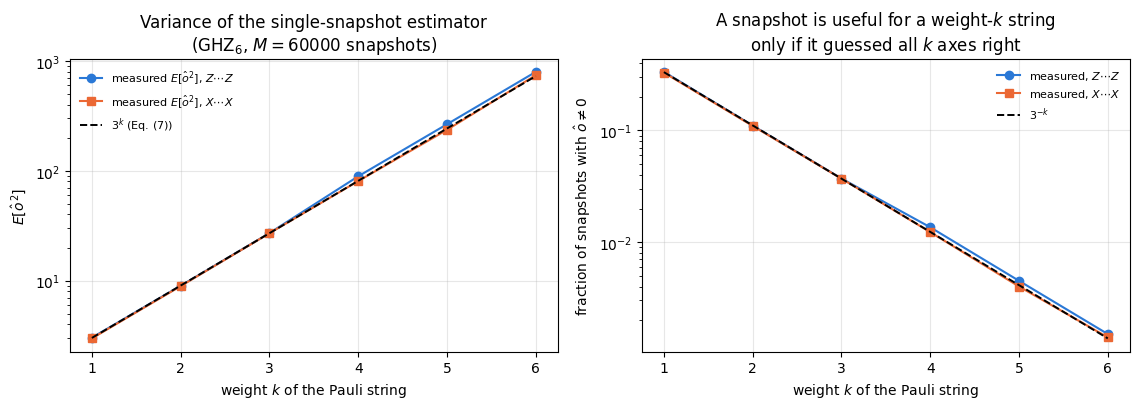

In [9]:
# ==============================================================================
# FIGURE: where the variance comes from -- the distribution of single-snapshot values
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ks = np.arange(1, N_VAR + 1)
e2_meas = np.array([float((vals_var[:, i] ** 2).mean()) for i in range(N_VAR)])
axes[0].semilogy(ks, e2_meas, MARKERS[0] + "-", color=PALETTE[0], label=r"measured $E[\hat o^2]$, $Z\cdots Z$")
e2_meas_x = np.array([float((vals_var[:, N_VAR + i] ** 2).mean()) for i in range(N_VAR)])
axes[0].semilogy(ks, e2_meas_x, MARKERS[1] + "-", color=PALETTE[1], label=r"measured $E[\hat o^2]$, $X\cdots X$")
axes[0].semilogy(ks, 3.0 ** ks, "k--", lw=1.4, label=r"$3^k$ (Eq. (7))")
axes[0].set_xlabel("weight $k$ of the Pauli string"); axes[0].set_ylabel(r"$E[\hat o^{\,2}]$")
axes[0].set_title(f"Variance of the single-snapshot estimator\n(GHZ$_{{{N_VAR}}}$, $M={M_VAR}$ snapshots)")
axes[0].legend(fontsize=8)

frac_z = np.array([float(jnp.mean(vals_var[:, i] != 0)) for i in range(N_VAR)])
frac_x = np.array([float(jnp.mean(vals_var[:, N_VAR + i] != 0)) for i in range(N_VAR)])
axes[1].semilogy(ks, frac_z, MARKERS[0] + "-", color=PALETTE[0], label=r"measured, $Z\cdots Z$")
axes[1].semilogy(ks, frac_x, MARKERS[1] + "-", color=PALETTE[1], label=r"measured, $X\cdots X$")
axes[1].semilogy(ks, 3.0 ** (-ks), "k--", lw=1.4, label=r"$3^{-k}$")
axes[1].set_xlabel("weight $k$ of the Pauli string")
axes[1].set_ylabel(r"fraction of snapshots with $\hat o\neq0$")
axes[1].set_title("A snapshot is useful for a weight-$k$ string\nonly if it guessed all $k$ axes right")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The left panel confirms Eq. (7) over three orders of magnitude and for two different Pauli families. The right panel shows *why*
the variance is $3^k$ and warns about what follows: the single-snapshot estimator of a weight-$k$ string is $0$ with probability
$1-3^{-k}$ (the measured fraction of useful snapshots follows $3^{-k}$ exactly) and $\pm3^k$ with the remaining probability.
It is an extremely **heavy-tailed** random variable. Its mean is still the right thing, but a sample mean of heavy-tailed variables
converges *badly in the tails*: with $M=100$ and $k=6$ one expects $M\,3^{-k}\approx0.14$ non-zero contributions, so most data sets
return exactly $0$ and a few return something very large. Section 6.3 treats this.

### 6.2 The shadow norm and the sample complexity

For a general observable $O$ the relevant quantity is the worst-case single-snapshot second moment, called the **shadow norm**
(Huang, Kueng and Preskill 2020):

$$\lVert O\rVert_{\rm shadow}^2=\max_{\sigma\ \text{state}}\ \mathbb E_{U}\sum_b\langle b\vert U\sigma U^\dagger\vert b\rangle\,
  \Big(\langle b\vert U\,\mathcal M^{-1}(O)\,U^\dagger\vert b\rangle\Big)^{2}\;\ge\;\mathrm{Var}(\hat o)+\langle O\rangle^2 .$$

It is a norm on observables that depends on the measurement ensemble, and it is the only thing that matters for the cost:
$M\gtrsim\lVert O\rVert^2_{\rm shadow}/\varepsilon^2$ snapshots give accuracy $\varepsilon$. The three facts we need:

| ensemble | observable | shadow norm |
|---|---|---|
| random Pauli bases | Pauli string of weight $k$ | exactly $3^{k}$ (Eq. (7)) |
| random Pauli bases | any $O$ supported on $k$ qubits | $\le 4^{k}\lVert O\rVert_\infty^2$ (quoted) |
| global Clifford | any $O$ | $\le 3\,\mathrm{Tr}(O_0^2)$, $O_0=O-\tfrac{\mathrm{Tr}O}{2^N}\mathbb 1$ (quoted) |

The first line we derived; it is also Lemma 3 of Huang, Kueng and Preskill (2020), who prove that the maximum over states is
attained for every state, so the shadow norm of a weight-$k$ Pauli string is exactly $3^k$. The second line is their
Proposition 3 and the third is their Proposition 1; we quote both without proof — but we will *measure* both in Section 10,
which is the honest thing to do with a quoted bound. Proposition 1 also gives a matching **lower** bound for the global
ensemble, $\mathrm{Tr}(O_0^2)\le\lVert O_0\rVert_{\rm shadow}^2$, so for global shadows the third line is tight up to the
factor $3$.

The third line matters because $\mathrm{Tr}(O_0^2)$ does not grow with $N$ for an observable like a fidelity
$O=\vert\psi\rangle\langle\psi\vert$, where $\mathrm{Tr}(O^2)=1$. Global shadows estimate a fidelity with $O(1/\varepsilon^2)$
snapshots for *any* number of qubits. Local (Pauli) shadows cannot: a fidelity is an $N$-local observable and its Pauli shadow
norm grows exponentially. Section 10.3 shows both effects.

### 6.3 Many observables at once: median of means

Suppose we want $K$ observables, each to accuracy $\varepsilon$, all of them correct simultaneously with probability $1-\delta$.
The naive route — sample mean plus a union bound over $K$ Gaussian tails — is fine when the estimator is light-tailed, and bad
when it is not (right panel of the figure above). The textbook cure is the **median-of-means** estimator:

1. split the $M$ snapshots into $G$ disjoint groups of size $M/G$;
2. compute the sample mean $\mu_g$ inside each group;
3. return the **median** of $\mu_1,\dots,\mu_G$.

*Why it works.* Let $\sigma^2=\mathrm{Var}(\hat o)$. Each group mean has variance $\sigma^2G/M$, so by Chebyshev

$$\Pr\big[\,\lvert\mu_g-\langle O\rangle\rvert>\varepsilon\,\big]\le\frac{\sigma^2G}{M\varepsilon^2}\le\frac14
  \qquad\text{provided}\qquad \frac MG\ge\frac{4\sigma^2}{\varepsilon^2}.$$

The median can only be wrong if at least half of the groups are wrong. The number $B$ of bad groups is binomial with success
probability $p\le1/4$, and Hoeffding's inequality gives

$$\Pr\left[B\ge\frac G2\right]\le\exp\left(-2G\left(\tfrac12-\tfrac14\right)^2\right)=e^{-G/8}.$$

Choosing $G=8\log(K/\delta)$ makes this at most $\delta/K$, and a union bound over the $K$ observables gives $\delta$ overall.
Multiplying the two conditions:

$$\boxed{\ M\;\ge\;32\,\log\!\left(\frac K\delta\right)\,\frac{\max_i\lVert O_i\rVert^2_{\rm shadow}}{\varepsilon^2}\ } \tag{8}$$

— **logarithmic in the number of observables**, which is Aaronson's shadow-tomography statement made into a runnable
algorithm. (Huang, Kueng and Preskill split the same budget as $G=2\log(2K/\delta)$ groups of $34\max_i\lVert O_i\rVert^2_{\rm shadow}/\varepsilon^2$
snapshots each, i.e. a total constant of $68$ where our bookkeeping gives $32$; only the scaling matters.)
Equation (8) is a *worst-case guarantee*, and its only input is the variance. A tail bound for the plain sample mean cannot
be obtained from the variance alone: Hoeffding's inequality applied to $\hat o$ needs its **range**, which for a weight-$k$
Pauli string is $2\cdot3^k$ rather than $\sqrt{3^k}$, and the resulting requirement $M\ge2\cdot9^k\log(2/\delta)/\varepsilon^2$
is larger than Eq. (8) by a factor $3^k/16$ (up to the ratio of the two logarithms) — exponential in the weight.
The measurement below compares the two estimators empirically, where no such bound is involved.

In [10]:
# ==============================================================================
# STEP 4: median of means, bootstrap error bars, and the heavy-tail test
# ==============================================================================
def median_of_means(values, n_groups):
    """Median-of-means estimator, per column of an (M, K) array of single-snapshot values.

    MATH   split into G groups of M/G, average inside each group, take the median over groups.
    IMPL   reshape (G, M/G, K) -> mean over axis 1 -> median over axis 0. Requires G | M (we trim).
    """
    Mn, K = values.shape
    g = Mn // n_groups
    v = values[: g * n_groups].reshape(n_groups, g, K)
    return jnp.median(v.mean(axis=1), axis=0)


def bootstrap_std(key, values, n_boot=200):
    """Bootstrap standard deviation of the sample mean, per column of an (M, K) array.

    MATH   resample the M snapshots with replacement B times; the spread of the B means is the error bar.
    IMPL   a resample is a multiplicity vector: counts = zeros(M).at[idx].add(1) -- then the resampled mean
           is the matrix product counts @ values / M. vmap over B resamples: ONE (B, M) x (M, K) matmul.
    JAX    this avoids materialising B x M x K numbers, which a naive `values[idx]` gather would do.
    """
    Mn = values.shape[0]

    def one(k):
        idx = jax.random.randint(k, (Mn,), 0, Mn)
        return jnp.zeros(Mn, dtype=RDTYPE).at[idx].add(1.0)

    counts = jax.vmap(one)(jax.random.split(key, n_boot))              # (B, M)
    return (counts @ values / Mn).std(axis=0)


# --- EXPERIMENT: mean vs median of means, over many independent data sets ---------------------------
N_MOM, M_MOM, R_MOM, G_MOM = 6, 2430, 200, 9     # 2430 = 30 x 3^4: ~30 useful snapshots for a weight-4 string
MOM_LAB = ("ZZZZII", "ZZIIII")                   # weights 4 and 2, both with <P> = 1 on GHZ_6
psi_mom = ghz_state(N_MOM)
bases_mom, bits_mom = collect_shadows(jax.random.PRNGKey(31), psi_mom, R_MOM * M_MOM)
vals_mom = snapshot_values(bases_mom, bits_mom, pauli_digits(list(MOM_LAB))).reshape(R_MOM, M_MOM, 2)
exact_mom = np.array([float(expect_pauli_string(psi_mom, {q: c for q, c in enumerate(lab) if c != "I"}))
                      for lab in MOM_LAB])

err_mean = np.abs(np.asarray(vals_mom.mean(axis=1)) - exact_mom[None, :])
err_mom = np.abs(np.asarray(jax.vmap(partial(median_of_means, n_groups=G_MOM))(vals_mom)) - exact_mom[None, :])
print(f"{R_MOM} independent data sets of M = {M_MOM} snapshots each, GHZ_{N_MOM}, {G_MOM} groups")
print(f"predicted sd of the sample mean: weight 4 -> {np.sqrt((81 - 1) / M_MOM):.3f}, "
      f"weight 2 -> {np.sqrt((9 - 1) / M_MOM):.3f}\n")
print(f"{'observable':>12s} {'k':>2s} {'estimator':>16s} {'median err':>11s} {'90th pct':>9s} "
      f"{'99th pct':>9s} {'worst':>8s}")
for i, lab in enumerate(MOM_LAB):
    k = sum(c != "I" for c in lab)
    for name, e in (("sample mean", err_mean[:, i]), ("median of means", err_mom[:, i])):
        print(f"{lab:>12s} {k:2d} {name:>16s} {np.median(e):11.3f} {np.percentile(e, 90):9.3f} "
              f"{np.percentile(e, 99):9.3f} {e.max():8.3f}")
ratio_mom = np.percentile(err_mom[:, 0], 90) / np.percentile(err_mean[:, 0], 90)
print(f"\nCHECKPOINT 90th-percentile error of the weight-4 estimator: median of means / sample mean = {ratio_mom:.2f}")
assert ratio_mom > 1.0       # the claim of the text: at THIS budget MoM does not beat the mean in the tail

200 independent data sets of M = 2430 snapshots each, GHZ_6, 9 groups
predicted sd of the sample mean: weight 4 -> 0.181, weight 2 -> 0.057

  observable  k        estimator  median err  90th pct  99th pct    worst
      ZZZZII  4      sample mean       0.133     0.300     0.468    0.700
      ZZZZII  4  median of means       0.100     0.400     0.700    0.800
      ZZIIII  2      sample mean       0.039     0.089     0.137    0.152
      ZZIIII  2  median of means       0.033     0.100     0.167    0.200

CHECKPOINT 90th-percentile error of the weight-4 estimator: median of means / sample mean = 1.33


At this budget the two estimators are comparable, and the sample mean is the better of the two in the tail: for the weight-4
string its $90$th-percentile error is $0.30$ against $0.40$ for the median of means, and its worst case over $200$ data sets is
$0.70$ against $0.80$. The median of means wins only at the median itself ($0.10$ against $0.13$). The reason is visible in the
numbers: with $G=9$ groups of $270$ snapshots, a group contains on average $270\cdot3^{-4}\approx3.3$ useful snapshots, so each
group mean is a coarse, strongly quantised estimate (its possible values are multiples of $3^4/270=0.3$) and the median of nine
such numbers inherits that coarseness. Median of means costs a factor $G$ in the effective sample size of every group; the
condition $M/G\ge4\sigma^2/\varepsilon^2$ in the derivation is exactly the statement that a group must already be a usable
estimate on its own.

The second half of the explanation is that at this budget the sample mean is already close to Gaussian while a group mean is
not. A data set contains $M3^{-4}\approx30$ useful snapshots, enough for the central limit theorem; a group contains three.
Note what does *not* explain the outcome: the fact that $\hat o$ is bounded by $3^k$ buys nothing here. Hoeffding's inequality
with the range $2\cdot3^4=162$ gives, at $M=2430$ and $\varepsilon=0.3$, the bound
$2\exp(-2M\varepsilon^2/162^2)=1.97$ — vacuous, as the factor $3^k/16$ of Section 6.3 already announced. Equation (8) is the
statement that survives at *rigorous* budgets, where both bounds become non-trivial and the variance-only bound is the better
of the two; at the budgets an experiment actually uses, neither is informative and the honest tool is the measured spread.

> **Numerical practice.** Use the median of means when a rigorous simultaneous guarantee for many observables is the deliverable,
> and check that $M/G$ is large enough for a single group to be meaningful. For reporting one well-sampled number, use the sample
> mean with a bootstrap error bar. The rest of this notebook does the latter and prints the median of means alongside.

## 7. One data set, many observables: the critical Ising chain

The protocol is now applied to a many-body state. We take the ground state of the transverse-field Ising model at
its critical point,

$$H=-\sum_{i=0}^{N-2}Z_iZ_{i+1}-h\sum_{i=0}^{N-1}X_i,\qquad h=1,$$

on $N=8$ qubits (Pauli convention, open chain — see
[11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb)),
obtain it exactly with Lanczos, and then *pretend we do not know it*: we only get to run the randomised measurement.
From **one** data set of $M$ snapshots we predict

* the single-site magnetisation $\langle X_1\rangle$ (weight 1),
* the correlator $\langle Z_1Z_2\rangle$ (weight 2),
* the three-body correlator $\langle X_1X_2X_3\rangle$ (weight 3),
* **all** $N-1$ nearest-neighbour correlators $\langle Z_iZ_{i+1}\rangle$ and all $N$ fields $\langle X_i\rangle$,
* and therefore the **energy** $\langle H\rangle$, a sum of $2N-1=15$ Pauli strings.

None of these was decided before the data were taken.

In [11]:
# ==============================================================================
# PARAMETERS of the many-observable experiment
# ==============================================================================
N_ISING = 8            # qubits
H_FIELD = 1.0          # transverse field (critical point of the TFIM)
M_MAIN = 20000         # snapshots in the main data set  (= total number of runs of the machine)
N_BOOT = 200           # bootstrap resamples for the error bars

terms_tfim = heisenberg_terms(N_ISING, Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=-H_FIELD)
t0 = time.perf_counter()
E_exact, psi_tfim = lanczos_ground_state(terms_tfim, N_ISING, m=80, key=jax.random.PRNGKey(0))
t_gs = time.perf_counter() - t0
print(f"TFIM ground state: N = {N_ISING}, h = {H_FIELD}, E_0 = {E_exact:.6f}  (Lanczos, {t_gs:.2f} s)")
print(f"check <psi|H|psi> = {float(energy(terms_tfim, psi_tfim)):.6f}")

t0 = time.perf_counter()
bases_main, bits_main = collect_shadows(jax.random.PRNGKey(2024), psi_tfim, M_MAIN)
jax.block_until_ready(bases_main)
t_collect = time.perf_counter() - t0
print(f"\ncollected {M_MAIN} snapshots in {t_collect:.2f} s  "
      f"-> data set = 2 x {M_MAIN} x {N_ISING} integers = {2 * M_MAIN * N_ISING / 1e6:.2f} M numbers")
print(f"(for comparison, the density matrix of {N_ISING} qubits has 4^{N_ISING} = {4 ** N_ISING} complex entries)")

TFIM ground state: N = 8, h = 1.0, E_0 = -9.837951  (Lanczos, 14.87 s)


check <psi|H|psi> = -9.837951



collected 20000 snapshots in 12.05 s  -> data set = 2 x 20000 x 8 integers = 0.32 M numbers
(for comparison, the density matrix of 8 qubits has 4^8 = 65536 complex entries)


In [12]:
# ==============================================================================
# EXPERIMENT: every observable we want, from the ONE data set above
# ==============================================================================
def ising_observables(N):
    """Labels of the observables we predict: the three named ones, then all <Z_i Z_{i+1}> and all <X_i>."""
    named = ["I" * 1 + "X" + "I" * (N - 2),                                  # <X_1>
             "I" + "ZZ" + "I" * (N - 3),                                     # <Z_1 Z_2>
             "I" + "XXX" + "I" * (N - 4)]                                    # <X_1 X_2 X_3>
    zz = ["I" * i + "ZZ" + "I" * (N - i - 2) for i in range(N - 1)]
    xx = ["I" * i + "X" + "I" * (N - i - 1) for i in range(N)]
    return named, zz, xx


named_lab, zz_lab, x_lab = ising_observables(N_ISING)
all_lab = named_lab + zz_lab + x_lab
vals_main = snapshot_values(bases_main, bits_main, pauli_digits(all_lab))
mean_main, sem_main = shadow_mean(vals_main)
boot_main = bootstrap_std(jax.random.PRNGKey(5), vals_main, N_BOOT)
exact_main = jnp.asarray([expect_pauli_string(psi_tfim, {q: c for q, c in enumerate(lab) if c != "I"})
                          for lab in all_lab])

print(f"{'observable':>16s} {'exact':>8s} {'shadow estimate':>20s} {'bootstrap sd':>13s} {'deviation':>10s}")
for i, lab in enumerate(named_lab):
    name = {0: "<X_1>", 1: "<Z_1 Z_2>", 2: "<X_1 X_2 X_3>"}[i]
    z = (float(mean_main[i]) - float(exact_main[i])) / float(sem_main[i])
    print(f"{name:>16s} {float(exact_main[i]):8.4f} {float(mean_main[i]):9.4f} +- {float(sem_main[i]):.4f} "
          f"{float(boot_main[i]):13.4f} {z:+9.2f} sd")

# the energy: E = - sum <Z_i Z_{i+1}> - h sum <X_i>; the coefficient vector turns snapshot values into E
n_named = len(named_lab)
coef = jnp.concatenate([jnp.zeros(n_named), -jnp.ones(len(zz_lab)), -H_FIELD * jnp.ones(len(x_lab))])
E_per_snapshot = vals_main @ coef                            # one energy estimate per snapshot (a linear combination)
E_hat, E_sem = float(E_per_snapshot.mean()), float(E_per_snapshot.std() / np.sqrt(M_MAIN))
E_boot = float(bootstrap_std(jax.random.PRNGKey(6), E_per_snapshot[:, None], N_BOOT)[0])
E_mom = float(median_of_means(E_per_snapshot[:, None], 9)[0])
print(f"\nenergy from the same {M_MAIN} snapshots ({len(zz_lab) + len(x_lab)} Pauli strings):")
print(f"   exact                 E_0     = {E_exact:.4f}")
print(f"   shadow (sample mean)  E_hat   = {E_hat:.4f} +- {E_sem:.4f} (standard error)  "
      f"+- {E_boot:.4f} (bootstrap)")
print(f"   shadow (median of 9 means)    = {E_mom:.4f}")
print(f"   deviation from exact          = {(E_hat - E_exact) / E_sem:+.2f} standard errors")
assert abs(E_hat - E_exact) < 5 * E_sem
assert abs(E_boot - E_sem) < 0.3 * E_sem            # bootstrap reproduces the analytic standard error

      observable    exact      shadow estimate  bootstrap sd  deviation
           <X_1>   0.7351    0.7584 +- 0.0112        0.0113     +2.08 sd
       <Z_1 Z_2>   0.5579    0.5675 +- 0.0207        0.0197     +0.46 sd
   <X_1 X_2 X_3>   0.6676    0.7452 +- 0.0372        0.0436     +2.08 sd



energy from the same 20000 snapshots (15 Pauli strings):
   exact                 E_0     = -9.8380
   shadow (sample mean)  E_hat   = -9.9390 +- 0.0644 (standard error)  +- 0.0677 (bootstrap)
   shadow (median of 9 means)    = -9.8789
   deviation from exact          = -1.57 standard errors


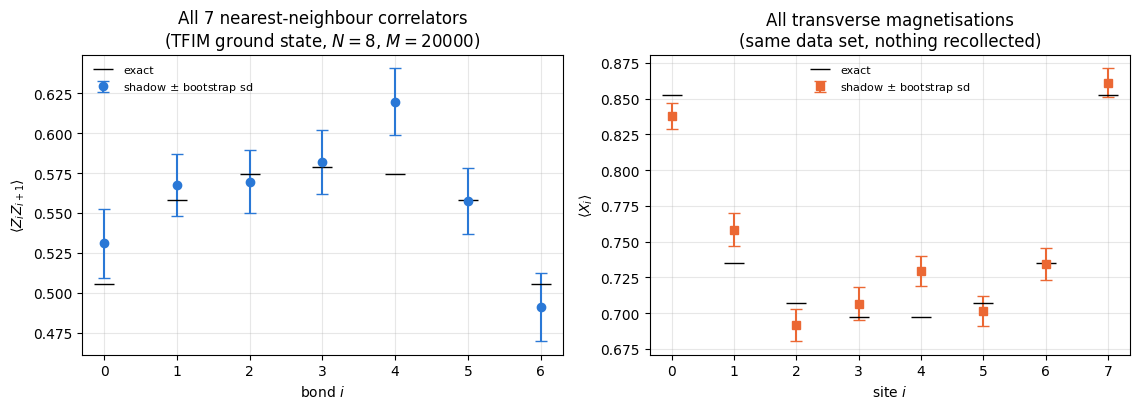

CHECKPOINT all 18 observables: largest deviation from the exact value = 2.85 standard errors; mean |deviation| = 1.08 sd (expected ~0.8 for unbiased Gaussian errors)


In [13]:
# ==============================================================================
# FIGURE: all nearest-neighbour correlators and all fields, from one data set
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
i0 = n_named
zz_idx = np.arange(i0, i0 + len(zz_lab))
x_idx = np.arange(i0 + len(zz_lab), len(all_lab))

axes[0].errorbar(np.arange(len(zz_lab)), np.asarray(mean_main)[zz_idx], yerr=np.asarray(boot_main)[zz_idx],
                 fmt=MARKERS[0], color=PALETTE[0], capsize=4, label=r"shadow $\pm$ bootstrap sd")
axes[0].plot(np.arange(len(zz_lab)), np.asarray(exact_main)[zz_idx], "k_", ms=14, label="exact")
axes[0].set_xlabel("bond $i$"); axes[0].set_ylabel(r"$\langle Z_iZ_{i+1}\rangle$")
axes[0].set_title(fr"All {len(zz_lab)} nearest-neighbour correlators" "\n"
                  fr"(TFIM ground state, $N={N_ISING}$, $M={M_MAIN}$)")
axes[0].legend(fontsize=8)

axes[1].errorbar(np.arange(len(x_lab)), np.asarray(mean_main)[x_idx], yerr=np.asarray(boot_main)[x_idx],
                 fmt=MARKERS[1], color=PALETTE[1], capsize=4, label=r"shadow $\pm$ bootstrap sd")
axes[1].plot(np.arange(len(x_lab)), np.asarray(exact_main)[x_idx], "k_", ms=14, label="exact")
axes[1].set_xlabel("site $i$"); axes[1].set_ylabel(r"$\langle X_i\rangle$")
axes[1].set_title("All transverse magnetisations\n(same data set, nothing recollected)")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

dev = np.abs(np.asarray(mean_main - exact_main)) / np.asarray(sem_main)
print(f"CHECKPOINT all {len(all_lab)} observables: largest deviation from the exact value = {dev.max():.2f} "
      f"standard errors; mean |deviation| = {dev.mean():.2f} sd (expected ~0.8 for unbiased Gaussian errors)")
assert dev.max() < 4.5

Every correlator and every magnetisation of the chain, with error bars, from a data set collected before any of them was chosen.
The largest deviation over the $18$ observables is $2.85$ standard errors and the mean absolute deviation is $1.08$ standard
errors, against the $0.8$ expected for unbiased Gaussian errors. The two numbers are not in conflict: the $18$ deviations are
strongly correlated (they are computed from the same snapshots, and most snapshots contribute to several of them), so the
average of $\lvert z\rvert$ over the list behaves like an average over far fewer than $18$ independent draws and its own
standard deviation is of order $0.5$. The bootstrap standard deviations reproduce the analytic $\sigma/\sqrt M$ (for the energy,
$0.068$ against $0.064$), as they must for a plain sample mean; it is for *non-linear* functions of the snapshots — a purity,
a projected density matrix, a fidelity after projection — that the bootstrap is the only error bar available.

The boundary effects of the open chain are resolved: the exact $\langle Z_iZ_{i+1}\rangle$ rises from $0.506$ on the end bonds
through $0.558$ and $0.574$ to $0.579$ on the central bond, while $\langle X_i\rangle$ falls from $0.852$ at the ends to
$0.697$ in the middle. An end spin has only one neighbour to be correlated with and therefore aligns more easily with the
transverse field.

The energy comes out as $-9.939\pm0.064$ against the exact $-9.838$, a deviation of $1.6$ standard errors. Its estimator is a
linear combination of $15$ Pauli strings, which lets us build **one energy estimate per snapshot** (`vals_main @ coef`) and treat
the energy as a single random variable. Its variance is not the sum of the fifteen individual variances — the estimators are
correlated, because they are computed from the same snapshot — and the sample mean handles that automatically. This is how
shadows are used inside a variational algorithm, where the energy is the cost function.

## 8. Convergence with the number of snapshots

Equation (7) predicts a standard error $\sqrt{(3^k-\langle P\rangle^2)/M}$ for a weight-$k$ string: a $M^{-1/2}$ law with a
prefactor that grows as $3^{k/2}$. We measure it over three decades in $M$ and for four observables. To give every point many
independent realisations at no extra cost, each long run is cut into disjoint blocks of length $M$; every block is an
independent data set, and the root-mean-square error over blocks estimates the standard deviation of the estimator.

convergence scan: 4 x 120000 snapshots collected in 62.5 s; 4800 independent blocks at M = 100, 16 at M = 30000


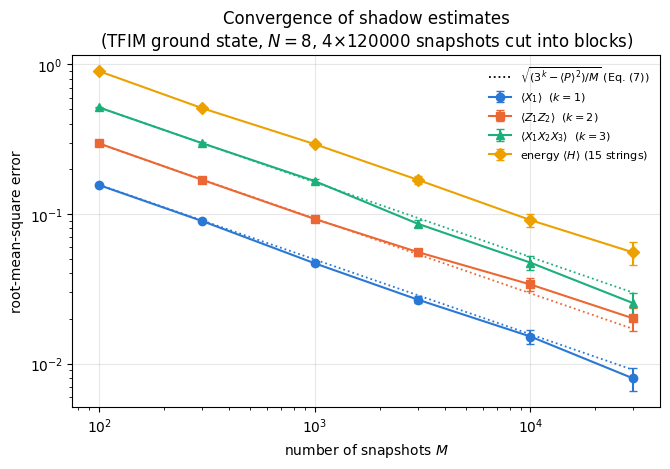


      M                <X_1> (k=1)             <Z_1Z_2> (k=2)          <X_1X_2X_3> (k=3)
    100      0.1559 (Eq.(7): 0.1568)      0.2959 (Eq.(7): 0.2948)      0.5151 (Eq.(7): 0.5153)
    300      0.0897 (Eq.(7): 0.0905)      0.1692 (Eq.(7): 0.1702)      0.2974 (Eq.(7): 0.2975)
   1000      0.0468 (Eq.(7): 0.0496)      0.0925 (Eq.(7): 0.0932)      0.1658 (Eq.(7): 0.1630)
   3000      0.0268 (Eq.(7): 0.0286)      0.0556 (Eq.(7): 0.0538)      0.0861 (Eq.(7): 0.0941)
  10000      0.0152 (Eq.(7): 0.0157)      0.0338 (Eq.(7): 0.0295)      0.0473 (Eq.(7): 0.0515)
  30000      0.0079 (Eq.(7): 0.0091)      0.0200 (Eq.(7): 0.0170)      0.0253 (Eq.(7): 0.0298)

CHECKPOINT fitted log-log slopes: -0.518, -0.469, -0.529, -0.490  (expected -0.500)
CHECKPOINT measured rms error / Eq. (7): min 0.851, max 1.177 (expected 1; the large-M points average over only 16 blocks and scatter by ~18%)


In [14]:
# ==============================================================================
# EXPERIMENT: error vs number of snapshots, for observables of weight 1, 2, 3 and for the energy
# ==============================================================================
M_GRID = np.array([100, 300, 1000, 3000, 10000, 30000])
M_LONG, R_CONV = 120000, 4                          # 4 long runs, cut into disjoint blocks of length M
dig_conv = pauli_digits(named_lab + zz_lab + x_lab)
exact_conv = np.asarray(exact_main)
ROOT_MEAN_SQ = lambda a: float(np.sqrt(np.mean(np.asarray(a) ** 2)))

t0 = time.perf_counter()
blocks = {m: [] for m in M_GRID}                    # [M] -> list of (error of X_1, Z_1Z_2, X_1X_2X_3, energy)
for r in range(R_CONV):
    bb, tt = collect_shadows(jax.random.PRNGKey(900 + r), psi_tfim, M_LONG)
    vv = np.asarray(snapshot_values(bb, tt, dig_conv))
    ee = vv @ np.asarray(coef)
    for m in M_GRID:                                # every disjoint block of length m is an independent data set
        n_blk = M_LONG // m
        mu = vv[: n_blk * m, :3].reshape(n_blk, m, 3).mean(1) - exact_conv[None, :3]
        en = ee[: n_blk * m].reshape(n_blk, m).mean(1) - E_exact
        blocks[m].append(np.concatenate([mu, en[:, None]], axis=1))
blocks = {m: np.concatenate(v, axis=0) for m, v in blocks.items()}
print(f"convergence scan: {R_CONV} x {M_LONG} snapshots collected in {time.perf_counter() - t0:.1f} s; "
      f"{blocks[M_GRID[0]].shape[0]} independent blocks at M = {M_GRID[0]}, "
      f"{blocks[M_GRID[-1]].shape[0]} at M = {M_GRID[-1]}")

rms = np.array([[ROOT_MEAN_SQ(blocks[m][:, i]) for i in range(4)] for m in M_GRID])
n_blocks = np.array([blocks[m].shape[0] for m in M_GRID], dtype=float)

fig, ax = plt.subplots(figsize=(6.8, 4.8))
names = [r"$\langle X_1\rangle$  ($k=1$)", r"$\langle Z_1Z_2\rangle$  ($k=2$)",
         r"$\langle X_1X_2X_3\rangle$  ($k=3$)", r"energy $\langle H\rangle$ (15 strings)"]
for i in range(4):
    ax.errorbar(M_GRID, rms[:, i], yerr=rms[:, i] / np.sqrt(2 * n_blocks), fmt=MARKERS[i] + "-",
                color=PALETTE[i], capsize=3, label=names[i])
for i, k in enumerate((1, 2, 3)):
    ax.loglog(M_GRID, np.sqrt((3.0 ** k - exact_conv[i] ** 2) / M_GRID), ":", color=PALETTE[i], lw=1.3)
ax.loglog([], [], "k:", lw=1.3, label=r"$\sqrt{(3^k-\langle P\rangle^2)/M}$ (Eq. (7))")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("number of snapshots $M$"); ax.set_ylabel("root-mean-square error")
ax.set_title(f"Convergence of shadow estimates\n(TFIM ground state, $N={N_ISING}$, "
             f"{R_CONV}$\\times${M_LONG} snapshots cut into blocks)")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"\n{'M':>7s} " + " ".join(f"{n:>26s}" for n in ("<X_1> (k=1)", "<Z_1Z_2> (k=2)", "<X_1X_2X_3> (k=3)")))
for j, m in enumerate(M_GRID):
    print(f"{m:7d} " + " ".join(f"{rms[j, i]:11.4f} (Eq.(7): {np.sqrt((3.0 ** (i + 1) - exact_conv[i] ** 2) / m):.4f})"
                                for i in range(3)))
slopes = [np.polyfit(np.log(M_GRID), np.log(rms[:, i]), 1)[0] for i in range(4)]
print(f"\nCHECKPOINT fitted log-log slopes: " + ", ".join(f"{s:+.3f}" for s in slopes) + "  (expected -0.500)")
assert max(abs(s + 0.5) for s in slopes) < 0.06
ratio7 = rms[:, :3] / np.array([[np.sqrt((3.0 ** (i + 1) - exact_conv[i] ** 2) / m) for i in range(3)] for m in M_GRID])
print(f"CHECKPOINT measured rms error / Eq. (7): min {ratio7.min():.3f}, max {ratio7.max():.3f} (expected 1; "
      f"the large-M points average over only {blocks[M_GRID[-1]].shape[0]} blocks and scatter by "
      f"~{100 / np.sqrt(2 * blocks[M_GRID[-1]].shape[0]):.0f}%)")
assert 0.8 < ratio7.min() and ratio7.max() < 1.25

The fitted log-log slopes are $-0.52$, $-0.47$, $-0.53$ and $-0.49$ against the expected $-1/2$, and the dotted reference lines
$\sqrt{(3^k-\langle P\rangle^2)/M}$ — *predicted* by Eq. (7), with no fitted parameter — lie on top of the measured points:
at $M=100$ the measured root-mean-square errors are $0.156$, $0.296$ and $0.515$ against the predicted $0.157$, $0.295$
and $0.515$. The vertical ordering is the $3^{k/2}$ prefactor: each extra qubit in the support costs a factor
$\sqrt3\approx1.7$ in accuracy at fixed budget, or a factor $3$ in budget at fixed accuracy. The scatter of the two largest-$M$
points is the finite number of blocks available there ($16$ at $M=3\cdot10^4$), not a failure of the law.

The energy sits above the three single strings but only by a factor of about two, although it is a sum of fifteen of them. Its
variance is not the sum of the fifteen individual variances: the strings are estimated from the same snapshots and are
correlated, and most snapshots contribute to several of them at once.

## 9. The local-Clifford variant: 24 rotations instead of 3

A natural-looking "improvement" is to replace the three Pauli bases by the full **single-qubit Clifford group**: the $24$ unitaries
that map Pauli operators to Pauli operators, generated by $H$ and $S$ (the engine builds them by breadth-first search in
`single_qubit_cliffords`). Geometrically they are the $24$ rotational symmetries of the Bloch-sphere octahedron. Drawing one at
random and measuring $Z$ certainly probes the Bloch sphere more democratically than choosing one of three axes.

It changes nothing, for the following reason. A Clifford $C$ maps the measurement of $Z$ into the measurement of $C^\dagger ZC$, which is
$\pm X$, $\pm Y$ or $\pm Z$ — those are the only Paulis a Clifford can produce. Each of the six signed axes is reached by exactly
$24/6=4$ of the group elements (the $24$ rotations act transitively on the $6$ **vertices** of the octahedron, and the stabiliser
of a vertex is the four-fold rotation about that axis, so $24=6\cdot4$ by the orbit-stabiliser theorem).
A global sign is irrelevant, because it only relabels the two outcomes $b=0\leftrightarrow1$, which are summed over in Eq. (1).
Hence the *induced distribution over measured axes* is uniform on $\{X,Y,Z\}$ — exactly the Pauli ensemble — and

$$\mathcal M_{\rm Clifford}=\mathcal M_{\rm Pauli}=\text{depolarising with }f=\tfrac13,\qquad
  \mathcal M^{-1}(A)=3A-\mathrm{Tr}(A)\mathbb 1 .$$

A second derivation of the same statement, needed again in Section 10: the single-qubit Clifford group is a **unitary
2-design** (Webb 2016; Zhu 2017 prove the much stronger statement that the multi-qubit Clifford group is a 3-design). Equation (1)
involves the ensemble only through its second moments, so *any* 2-design on one qubit gives the same channel — and for $d=2$ the
general 2-design result of Section 10.1 reads $\mathcal M(A)=(A+\mathrm{Tr}(A)\mathbb 1)/(d+1)=(A+\mathrm{Tr}(A)\mathbb 1)/3$,
which is Eq. (3) again.

Let us check both statements numerically, to machine precision, with the superoperator machinery of Section 4.

In [15]:
# ==============================================================================
# CHECKPOINT: the 24-element single-qubit Clifford ensemble gives exactly the Pauli channel
# ==============================================================================
CLIFF1 = single_qubit_cliffords()                    # (24, 2, 2)
S_cliff = measurement_channel(CLIFF1)
print(f"single-qubit Clifford group: {CLIFF1.shape[0]} elements")
print(f"CHECKPOINT M_Clifford vs M_Pauli                 : max error = {max_abs(S_cliff - S_pauli):.1e}")
print(f"CHECKPOINT M_Clifford vs depolarising with f=1/3 : max error = "
      f"{max_abs(S_cliff - depolarising_channel_matrix(2, 1 / 3)):.1e}")
assert max_abs(S_cliff - S_pauli) < 1e3 * TOL

# which axis does each Clifford measure?  C^dag Z C = +- X, Y or Z
axis_count = {s: 0 for s in ("+X", "-X", "+Y", "-Y", "+Z", "-Z")}
for C in CLIFF1:
    A = C.conj().T @ Z @ C
    for nm, P in (("X", X), ("Y", Y), ("Z", Z)):
        ov = float(jnp.real(jnp.trace(A @ P))) / 2
        if abs(abs(ov) - 1) < 1e-8:
            axis_count[("+" if ov > 0 else "-") + nm] += 1
print("\nmeasured axis C^dag Z C over the 24 Cliffords:", axis_count)
assert set(axis_count.values()) == {4}

# a Haar-random single-qubit ensemble is also a 2-design "on average": check by Monte Carlo
keys = jax.random.split(jax.random.PRNGKey(3), 20000)
S_haar1 = measurement_channel(jax.vmap(lambda k: haar_unitary(k, 2))(keys))
print(f"CHECKPOINT 20000 Haar-random 1-qubit unitaries vs the same channel: max error = "
      f"{max_abs(S_haar1 - S_pauli):.3f}  (Monte-Carlo noise ~ {1 / np.sqrt(20000):.3f})")
assert max_abs(S_haar1 - S_pauli) < 6 / np.sqrt(20000)

single-qubit Clifford group: 24 elements
CHECKPOINT M_Clifford vs M_Pauli                 : max error = 5.6e-16
CHECKPOINT M_Clifford vs depolarising with f=1/3 : max error = 7.8e-16



measured axis C^dag Z C over the 24 Cliffords: {'+X': 4, '-X': 4, '+Y': 4, '-Y': 4, '+Z': 4, '-Z': 4}


CHECKPOINT 20000 Haar-random 1-qubit unitaries vs the same channel: max error = 0.002  (Monte-Carlo noise ~ 0.007)


Exactly the same channel, to $10^{-16}$ — and the axis count confirms the geometric argument: each of the six signed axes is
measured by precisely four of the $24$ Cliffords. Haar-random single-qubit rotations, which are a $k$-design for every $k$, give
the same channel again within Monte-Carlo noise.

> **Common pitfall.** "More random rotations must be better" is wrong. What enters the estimator is the *second moment* of the
> ensemble, and any 2-design has the same second moment. A richer single-qubit ensemble costs more calibration in the laboratory
> and buys nothing. The interesting variation is not *more* random single-qubit rotations but **entangling** ones — Section 10.

## 10. The global variant: entangling Clifford circuits

### 10.1 The channel of a 2-design on the whole Hilbert space

Now let $\mathcal U$ be an ensemble of unitaries on the **full** $d=2^N$-dimensional space which is a unitary 2-design, i.e. whose
first two moments match the Haar measure. Equation (1) becomes, using that the random *state* $\vert\chi\rangle:=U^\dagger\vert b\rangle$
has, for each fixed $b$, the same first two moments as a Haar-random state (which is all the calculation below uses),

$$\mathcal M(\rho)=\sum_{b}\mathbb E_{\chi}\Big[\langle\chi\vert\rho\vert\chi\rangle\,\vert\chi\rangle\langle\chi\vert\Big]
  =d\,\mathbb E_{\chi}\Big[\langle\chi\vert\rho\vert\chi\rangle\,\vert\chi\rangle\langle\chi\vert\Big],$$

because all $d$ terms have the same marginal distribution. The remaining expectation is a **second moment of a random state**,
and there is one standard formula for it: the average of $\vert\chi\rangle\langle\chi\vert^{\otimes2}$ over Haar-random states is
the normalised projector onto the symmetric subspace of two copies,

$$\mathbb E_\chi\big[\vert\chi\rangle\langle\chi\vert^{\otimes2}\big]=\frac{P_{\rm sym}}{\binom{d+1}{2}}
  =\frac{2}{d(d+1)}\cdot\frac{\mathbb 1+\mathbb{S}}{2},$$

with $\mathbb S$ the swap of the two copies. (It must be proportional to $P_{\rm sym}$ by symmetry, and the constant follows from
the trace $\mathrm{Tr}P_{\rm sym}=\binom{d+1}{2}$.) Writing $\langle\chi\vert\rho\vert\chi\rangle\,\vert\chi\rangle\langle\chi\vert
=\mathrm{Tr}_2\big[(\mathbb 1\otimes\rho)\,\vert\chi\rangle\langle\chi\vert^{\otimes2}\big]$ and using
$\mathrm{Tr}_2[(\mathbb 1\otimes\rho)\mathbb S]=\rho$, $\mathrm{Tr}_2[(\mathbb 1\otimes\rho)\mathbb 1]=\mathrm{Tr}(\rho)\mathbb 1$:

$$\mathcal M(\rho)=d\cdot\frac{1}{d(d+1)}\Big(\rho+\mathrm{Tr}(\rho)\,\mathbb 1\Big)
  =\frac{\rho+\mathrm{Tr}(\rho)\,\mathbb 1}{d+1},\qquad
  \boxed{\ \mathcal M^{-1}(A)=(d+1)A-\mathrm{Tr}(A)\,\mathbb 1\ } \tag{9}$$

(verify: $\mathcal M\big((d+1)A-\mathrm{Tr}(A)\mathbb 1\big)=\frac{1}{d+1}\big[(d+1)A-\mathrm{Tr}(A)\mathbb 1+((d+1)\mathrm{Tr}A-d\,\mathrm{Tr}A)\mathbb 1\big]=A$).
For $N=1$, $d=2$ this reduces to $\mathcal M^{-1}(A)=3A-\mathrm{Tr}(A)\mathbb 1$, which is Eq. (4). For $N$ qubits the factor is
$2^N+1$ instead of $3^N$: **the global ensemble de-blurs much less aggressively**, which is exactly why its estimators of global
observables have small variance.

The single snapshot is now a rank-one object on the whole space,

$$\hat\rho=(d+1)\,\vert\chi\rangle\langle\chi\vert-\mathbb 1,\qquad\vert\chi\rangle=U^\dagger\vert b\rangle,$$

so $\hat o=\mathrm{Tr}(\hat\rho\,O)=(d+1)\langle\chi\vert O\vert\chi\rangle-\mathrm{Tr}(O)$: one inner product per snapshot.

### 10.2 The ensemble we actually sample

Equation (9) holds for a 2-design. The uniform distribution on the $N$-qubit Clifford group is one — in fact it is a 3-design
(Webb 2016; Zhu 2017) — but sampling it *exactly and uniformly* requires the canonical-form algorithms of stabiliser theory,
which are beyond this notebook. We therefore sample a concrete, explicitly stated **random Clifford circuit** ensemble:

> $L$ layers; each layer applies an independent uniformly random element of the $24$-element single-qubit Clifford group to
> **every** qubit, followed by CNOTs on the even bonds $(0,1),(2,3),\dots$ in even layers and on the odd bonds $(1,2),(3,4),\dots$
> in odd layers. We use $L=2N$.

This is *not* the uniform Clifford measure, and we do not claim it is. What we claim — and what **unbiasedness** needs — is that
its **second moments** match, i.e. that the measured channel equals Eq. (9). That is a testable statement, and we test it:
we build the superoperator of Eq. (1) for the sampled ensemble by Monte Carlo and compare it with Eq. (9), with the Monte-Carlo
error bar shown alongside. For reference we do the same for genuinely Haar-random unitaries, which are a $k$-design for every $k$.

> **Common pitfall.** A 2-design is enough for $\mathbb E[\hat\rho]=\rho$ and for nothing else. The *variance*
> $\mathbb E[\hat o^{\,2}]$ contains three factors of $U$ and three of $U^\dagger$, so it is a **third** moment of the ensemble;
> this is why Huang, Kueng and Preskill prove their global-Clifford variance bound using the fact that the Clifford group is a
> 3-design (Webb 2016; Zhu 2017 — see also notebook 10, where the Clifford group is shown to be a 3-design but *not* a
> 4-design). The channel test below therefore certifies the *unbiasedness* of the depth-$2N$ ensemble, not the variances
> measured in Section 10.3; read those as properties of the circuit we sample.

In [16]:
# ==============================================================================
# STEP 5: global (entangling) Clifford-circuit shadows
# ==============================================================================
def brickwall_bonds(N, depth):
    """CNOT pattern of the circuit: even bonds in even layers, odd bonds in odd layers."""
    return [[(i, i + 1) for i in range(l % 2, N - 1, 2)] for l in range(depth)]


def apply_clifford_circuit(psi, idx, bonds_per_layer, dagger=False):
    """Apply C (or C^dag) to a state tensor.  `idx` is an int array (L, N) of Clifford indices.

    MATH   C = prod_l  [ (x)_{bonds} CNOT ] [ (x)_q C_{l,q} ]     (layer l acts after layer l-1)
    JAX    CLIFF1[idx[l, q]] is a gather with a TRACED index -> the whole circuit is vmap-able over
           snapshots; the qubit indices and the bond list stay static Python objects.
    """
    N = psi.ndim
    if not dagger:
        for l, bonds in enumerate(bonds_per_layer):
            for q in range(N):
                psi = apply_gate(psi, CLIFF1[idx[l, q]], [q])
            for b in bonds:
                psi = apply_gate(psi, CNOT, b)
    else:                                                   # (AB)^dag = B^dag A^dag: reverse everything
        for l in range(len(bonds_per_layer) - 1, -1, -1):
            for b in reversed(bonds_per_layer[l]):
                psi = apply_gate(psi, CNOT, b)              # CNOT^dag = CNOT
            for q in range(N - 1, -1, -1):
                psi = apply_gate(psi, CLIFF1[idx[l, q]].conj().T, [q])
    return psi


def collect_global_shadows(key, psi, n_shadows, depth=None, chunk=2048):
    """Global-Clifford shadow data: returns the snapshot STATES |chi_m> = C_m^dag |b_m>, shape (M, 2^N).

    IMPL   per snapshot: draw (L, N) Clifford indices, rotate the state, sample one bit string b from the
           Born rule, then rotate the basis state |b> BACK with C^dag -- all matrix-free `apply_gate`s.
    NOTE   what an experiment really stores is (circuit, b): O(N^2) bits per snapshot. We materialise the
           2^N-dimensional |chi> only because it makes the estimators below one-liners at these small N.
    """
    N = psi.ndim
    depth = 2 * N if depth is None else depth
    bonds = brickwall_bonds(N, depth)

    def one(k):
        kc, ks = jax.random.split(k)
        idx = jax.random.randint(kc, (depth, N), 0, CLIFF1.shape[0])
        phi = apply_clifford_circuit(psi, idx, bonds)
        b = jax.random.categorical(ks, jnp.log(jnp.clip(jnp.abs(phi.reshape(-1)) ** 2, 1e-300, None)))
        ket = jnp.zeros(2 ** N, dtype=CDTYPE).at[b].set(1.0).reshape((2,) * N)
        return apply_clifford_circuit(ket, idx, bonds, dagger=True).reshape(-1)

    batch = jax.jit(jax.vmap(one))
    out, done = [], 0
    while done < n_shadows:
        c = min(chunk, n_shadows - done)
        out.append(batch(jax.random.split(jax.random.fold_in(key, done), c)))
        done += c
    return jnp.concatenate(out)


def clifford_circuit_unitary(idx, bonds):
    """The dense 2^N x 2^N matrix of one circuit -- for VALIDATION only (column j = C|e_j>)."""
    N = idx.shape[1]
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    return jax.vmap(lambda e: apply_clifford_circuit(e, idx, bonds).reshape(-1))(eye).T


# --- CHECKPOINT: the measured channel of the sampled ensemble vs Eq. (9) ---------------------------
N_CIRC = 4000                                        # circuits in the Monte-Carlo average
print(f"{'N':>2s} {'d':>3s} {'depth':>6s} {'max |M_sampled - Eq.(9)|':>25s} {'MC noise':>10s} "
      f"{'Haar reference':>15s}")
for n in (1, 2, 3):
    d, depth = 2 ** n, 2 * n
    bonds = brickwall_bonds(n, depth)
    idxs = jax.random.randint(jax.random.PRNGKey(11), (N_CIRC, depth, n), 0, CLIFF1.shape[0])
    Us = jax.lax.map(lambda ii: clifford_circuit_unitary(ii, bonds), idxs)
    S_glob = measurement_channel(Us)
    eye_d = jnp.eye(d, dtype=CDTYPE)                     # Eq. (9):  M(A) = (A + Tr(A) 1) / (d+1)
    S_pred = (jnp.einsum("ai,cj->acij", eye_d, eye_d)
              + jnp.einsum("ac,ij->acij", eye_d, eye_d)).reshape(d * d, d * d) / (d + 1)
    Uh = jax.vmap(lambda k: haar_unitary(k, d))(jax.random.split(jax.random.PRNGKey(12), N_CIRC))
    err_h = max_abs(measurement_channel(Uh) - S_pred)
    print(f"{n:2d} {d:3d} {depth:6d} {max_abs(S_glob - S_pred):25.4f} {1 / np.sqrt(N_CIRC):10.4f} {err_h:15.4f}")
    # a 3-sigma window: tight enough to REJECT depths 1 and 2 at N = 3 (which give 0.077 and 0.071), see Exercise 5
    assert max_abs(S_glob - S_pred) < 3 / np.sqrt(N_CIRC)

 N   d  depth  max |M_sampled - Eq.(9)|   MC noise  Haar reference


 1   2      2                    0.0029     0.0158          0.0043


 2   4      4                    0.0114     0.0158          0.0040


 3   8      6                    0.0092     0.0158          0.0021


For $N=1,2,3$ the measured channel of the random-Clifford-circuit ensemble agrees with Eq. (9) within the Monte-Carlo error
$\sim1/\sqrt{4000}=0.016$, and so does the Haar reference. The circuits we sample are therefore a 2-design *for the purpose of
Eq. (1)*, which is what unbiasedness needs. This is a numerical statement about the depth we chose, not a theorem, and the test
does have the power to reject a shallower circuit: running the same measurement at $N=3$ with $L=1$ and $L=2$ gives
$0.077$ and $0.071$, five times the Monte-Carlo noise and well outside the $3\sigma$ window asserted above; removing the CNOT
layers altogether gives $0.077$ at any depth, since a product of local Cliffords stays a product of local Cliffords and
reproduces the *Pauli* channel instead of Eq. (9). Exercise 5 turns this into a depth scan.

### 10.3 Fidelity: where global shadows win and local shadows lose

Consider estimating the **fidelity with a pure target**, $F=\langle\psi_{\rm t}\vert\rho\vert\psi_{\rm t}\rangle$, i.e. the
observable $O=\vert\psi_{\rm t}\rangle\langle\psi_{\rm t}\vert$. It has $\mathrm{Tr}(O^2)=1$ independently of $N$, so the quoted
bound of Section 6.2 gives $\lVert O\rVert_{\rm shadow}^2\le3$ for global shadows — the cost of certifying a state does **not**
grow with its size. For local (Pauli) shadows, $O$ is an $N$-local observable, and the general bound $4^k\lVert O\rVert_\infty^2$
gives $4^N$: useless.

For a product target the variance can be computed exactly rather than bounded. Take $\vert\psi_{\rm t}\rangle=\vert0\rangle^{\otimes N}$ and the state
$\rho=\vert0\rangle\langle0\vert^{\otimes N}$. Then $O=\bigotimes_q\tfrac{\mathbb 1+Z_q}{2}$ and, by Eq. (5), the single-snapshot
estimator factorises:

$$\hat o=\prod_q\mathrm{Tr}\!\left[\frac{\mathbb 1+3(-1)^{b_q}P^{\rm meas}_q}{2}\cdot\frac{\mathbb 1+Z_q}{2}\right]
       =\prod_q\frac{1+3(-1)^{b_q}\big[P^{\rm meas}_q=Z\big]}{2}.$$

Each factor equals $2$ (axis $Z$, bit $0$), $-1$ (axis $Z$, bit $1$) or $\tfrac12$ (axis $X$ or $Y$). On the state
$\vert0\rangle^{\otimes N}$ the bit is always $0$ when the axis is $Z$, so the factor is $2$ with probability $\tfrac13$ and
$\tfrac12$ with probability $\tfrac23$, giving

$$\mathbb E[\hat o^{\,2}]=\prod_q\left(\frac13\cdot4+\frac23\cdot\frac14\right)=\left(\frac32\right)^{N} . \tag{10}$$

So the variance of the local-shadow fidelity estimator grows as $1.5^N$: exponential, though with a smaller base than the
worst-case bound $4^N$. Let us measure Eq. (10), measure the same thing for a GHZ target, and compare with global shadows.

To estimate a fidelity from *local* shadows without building any matrix we use the product form of Eq. (5) once more:
$\hat o=\langle\psi_{\rm t}\vert\big(\bigotimes_qA_q\big)\vert\psi_{\rm t}\rangle$ is $N$ `apply_gate` einsums on the target state
followed by one inner product.

In [17]:
# ==============================================================================
# STEP 6: fidelity estimators for both ensembles
# ==============================================================================
def shadow_fidelity_local(bases, bits, psi_t):
    """Single-snapshot estimates of <psi_t|rho|psi_t> from PAULI shadows.

    MATH   o_m = <psi_t| (x)_q A_q^{(m)} |psi_t>,  A_q = 3 U_q^dag|b_q><b_q|U_q - 1 = SNAP1[basis, bit]
    IMPL   N apply_gate einsums + one vdot per snapshot; vmap over snapshots. No 2^N x 2^N matrix.
    """
    N = psi_t.ndim

    def one(bb, ss):
        phi = psi_t
        for q in range(N):
            phi = apply_gate(phi, SNAP1[bb[q], ss[q]], [q])
        return jnp.real(jnp.vdot(psi_t, phi))

    return jax.vmap(one)(bases, bits)


def shadow_fidelity_global(chis, psi_t):
    """Single-snapshot estimates from GLOBAL shadows:  o_m = (d+1) |<psi_t|chi_m>|^2 - 1."""
    d = chis.shape[1]
    return (d + 1) * jnp.abs(chis @ jnp.conj(psi_t.reshape(-1))) ** 2 - 1.0


def shadow_pauli_global(chis, psi_shape, ops):
    """Single-snapshot estimates of a traceless Pauli string from GLOBAL shadows: o_m = (d+1) <chi|P|chi>."""
    d = chis.shape[1]
    P_chi = jax.vmap(lambda c: apply_pauli_string_local(c.reshape(psi_shape), ops).reshape(-1))(chis)
    return (d + 1) * jnp.real(jnp.sum(jnp.conj(chis) * P_chi, axis=1))


def apply_pauli_string_local(psi, ops):
    """Apply a Pauli string given as {qubit: letter} -- the engine's apply_pauli_string, spelled out."""
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi


# --- EXPERIMENT: variance of two estimators vs system size, for both ensembles ---------------------
N_LIST_F = [2, 3, 4, 5, 6]
M_LOC, M_GLO = 20480, 4096
rows = []
t0 = time.perf_counter()
for n in N_LIST_F:
    ghz, prod = ghz_state(n), product_state("0" * n)
    zz_ops = {0: "Z", 1: "Z"}
    bb, tt = collect_shadows(jax.random.PRNGKey(41), ghz, M_LOC)
    bbp, ttp = collect_shadows(jax.random.PRNGKey(42), prod, M_LOC)
    o_loc_ghz = jax.jit(partial(shadow_fidelity_local, psi_t=ghz))(bb, tt)
    o_loc_prod = jax.jit(partial(shadow_fidelity_local, psi_t=prod))(bbp, ttp)
    o_loc_zz = snapshot_values(bb, tt, pauli_digits(["ZZ" + "I" * (n - 2)]))[:, 0]
    ch = collect_global_shadows(jax.random.PRNGKey(43), ghz, M_GLO)
    o_glo_ghz = shadow_fidelity_global(ch, ghz)
    o_glo_zz = shadow_pauli_global(ch, ghz.shape, zz_ops)
    rows.append((n, float((o_loc_zz ** 2).mean()), float((o_loc_ghz ** 2).mean()), float((o_loc_prod ** 2).mean()),
                 float((o_glo_zz ** 2).mean()), float((o_glo_ghz ** 2).mean()),
                 float(o_loc_ghz.mean()), float(o_glo_ghz.mean())))
print(f"variance scan done in {time.perf_counter() - t0:.1f} s "
      f"(local: {M_LOC} snapshots, global: {M_GLO} snapshots per N)\n")
print(f"{'N':>2s} | {'LOCAL shadows':^34s} | {'GLOBAL shadows':^22s} | {'F_hat (GHZ)':^19s}")
print(f"{'':>2s} | {'<ZZ>':>9s} {'F(GHZ)':>10s} {'F(|0..0>)':>12s} | {'<ZZ>':>10s} {'F(GHZ)':>10s} | "
      f"{'local':>9s} {'global':>9s}")
for r in rows:
    print(f"{r[0]:2d} | {r[1]:9.2f} {r[2]:10.2f} {r[3]:12.2f} | {r[4]:10.2f} {r[5]:10.2f} | "
          f"{r[6]:9.3f} {r[7]:9.3f}")
print(f"\nreference values:  3^2 = 9 (weight-2 Pauli, local)   (3/2)^N, Eq. (10)   "
      f"3 Tr(O^2) = 3 (bound for global)")

# --- CHECKPOINT: the three laws the figure below claims -------------------------------------------
ratio_10 = np.array([r[3] / 1.5 ** r[0] for r in rows])          # local fidelity, product target, vs Eq. (10)
ratio_zz = np.array([r[1] / 9.0 for r in rows])                  # local weight-2 Pauli, vs 3^k = 9
print(f"CHECKPOINT local E[o^2] for the product-target fidelity / (3/2)^N: min {ratio_10.min():.3f}, "
      f"max {ratio_10.max():.3f}  (exact value 1; a heavy-tailed second moment at M = {M_LOC} scatters by a few percent)")
print(f"CHECKPOINT local E[o^2] for <Z_0Z_1> / 3^2 over N = {N_LIST_F[0]}..{N_LIST_F[-1]}: "
      f"min {ratio_zz.min():.3f}, max {ratio_zz.max():.3f}  (exact value 1, independent of N)")
print(f"CHECKPOINT global E[o^2] for the GHZ fidelity: max {max(r[5] for r in rows):.2f} "
      f"(quoted bound 3 Tr(O^2) = 3)")
assert 0.9 < ratio_10.min() and ratio_10.max() < 1.1
assert 0.95 < ratio_zz.min() and ratio_zz.max() < 1.05
assert max(r[5] for r in rows) < 3.3     # ideal global Clifford: <= 3 Tr(O^2) = 3; our depth-2N circuit approximates one

variance scan done in 56.5 s (local: 20480 snapshots, global: 4096 snapshots per N)

 N |           LOCAL shadows            |     GLOBAL shadows     |     F_hat (GHZ)    
   |      <ZZ>     F(GHZ)    F(|0..0>) |       <ZZ>     F(GHZ) |     local    global
 2 |      8.95       2.13         2.27 |       4.90       1.92 |     1.002     0.967
 3 |      8.95       2.63         3.31 |      10.40       2.31 |     1.002     0.980
 4 |      8.95       3.90         4.84 |      22.79       2.68 |     0.994     0.994
 5 |      8.95       5.47         7.20 |      55.83       2.82 |     0.973     0.997
 6 |      8.95       8.63        11.52 |     106.24       2.96 |     1.009     1.017

reference values:  3^2 = 9 (weight-2 Pauli, local)   (3/2)^N, Eq. (10)   3 Tr(O^2) = 3 (bound for global)
CHECKPOINT local E[o^2] for the product-target fidelity / (3/2)^N: min 0.949, max 1.011  (exact value 1; a heavy-tailed second moment at M = 20480 scatters by a few percent)
CHECKPOINT local E[o^2] for <Z_0Z_1> 

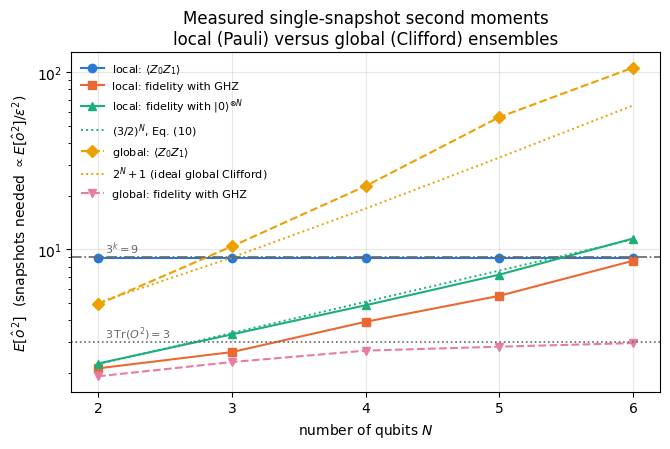

In [18]:
# ==============================================================================
# FIGURE: local and global shadows are complementary
# ==============================================================================
fig, ax = plt.subplots(figsize=(6.8, 4.6))
ns = np.array([r[0] for r in rows], dtype=float)
ax.semilogy(ns, [r[1] for r in rows], MARKERS[0] + "-", color=PALETTE[0], label=r"local: $\langle Z_0Z_1\rangle$")
ax.semilogy(ns, [r[2] for r in rows], MARKERS[1] + "-", color=PALETTE[1], label=r"local: fidelity with GHZ")
ax.semilogy(ns, [r[3] for r in rows], MARKERS[2] + "-", color=PALETTE[2],
            label=r"local: fidelity with $\vert0\rangle^{\otimes N}$")
ax.semilogy(ns, (1.5) ** ns, ":", color=PALETTE[2], lw=1.4, label=r"$(3/2)^N$, Eq. (10)")
ax.semilogy(ns, [r[4] for r in rows], MARKERS[3] + "--", color=PALETTE[3], label=r"global: $\langle Z_0Z_1\rangle$")
ax.semilogy(ns, 2.0 ** ns + 1.0, ":", color=PALETTE[3], lw=1.4, label=r"$2^N+1$ (ideal global Clifford)")
ax.semilogy(ns, [r[5] for r in rows], MARKERS[4] + "--", color=PALETTE[4], label=r"global: fidelity with GHZ")
ax.axhline(9.0, color="0.4", ls="-.", lw=1.2)
ax.axhline(3.0, color="0.4", ls=":", lw=1.2)
ax.text(N_LIST_F[0] + 0.05, 9.6, r"$3^k=9$", fontsize=8, color="0.4")
ax.text(N_LIST_F[0] + 0.05, 3.2, r"$3\,\mathrm{Tr}(O^2)=3$", fontsize=8, color="0.4")
ax.set_xticks(N_LIST_F); ax.set_xlabel("number of qubits $N$")
ax.set_ylabel(r"$E[\hat o^{\,2}]$  (snapshots needed $\propto E[\hat o^2]/\varepsilon^2$)")
ax.set_title("Measured single-snapshot second moments\nlocal (Pauli) versus global (Clifford) ensembles")
ax.legend(fontsize=8, ncol=1, loc="upper left")
fig.tight_layout(); plt.show()

Every curve in the figure is measured.

* **Local shadows, local observable** (blue): $8.95$ at every $N$ from $2$ to $6$, against the exact $3^k=9$ — the
  $N$-independence of Eq. (7).
* **Local shadows, fidelity** (green, orange): exponential. The product target gives $2.27,\,3.31,\,4.84,\,7.20,\,11.52$ against
  the derived $(3/2)^N=2.25,\,3.38,\,5.06,\,7.59,\,11.39$ of Eq. (10); the GHZ target grows at a similar rate
  ($2.13\to8.63$, a factor $1.4$ per qubit). Certifying a state with local randomised measurements costs exponentially many runs.
* **Global shadows, fidelity** (pink): $1.92\to2.96$, approaching but not exceeding the quoted bound
  $3\,\mathrm{Tr}(O^2)=3$ — a fidelity costs $O(1/\varepsilon^2)$ snapshots at any $N$.
* **Global shadows, local observable** (yellow): $4.90\to106.2$, a factor of about $2$ per qubit. Entangling the measurement
  destroys the locality that made Eq. (7) $N$-independent, and the values stay below the quoted bound $3\,\mathrm{Tr}(P^2)=3\cdot2^N$.

The yellow curve is the one place where the difference between the ideal global Clifford group and the depth-$2N$ circuit we
actually sample is visible, and it is worth spelling out, because it is exactly the third-moment gap flagged in Section 10.2.
For a *true* 3-design one can compute $\mathbb E[\hat o^{\,2}]$ in closed form. Averaging
$\vert\chi\rangle\langle\chi\vert^{\otimes3}$ over Haar-random states gives $P_{\rm sym}^{(3)}/\binom{d+2}{3}$, and contracting
it with $\rho\otimes O\otimes O$ for a traceless $O$ leaves only three of the six permutations, so that

$$\mathbb E\big[\hat o^{\,2}\big]=\frac{(d+1)\big(\mathrm{Tr}(O^2)+2\,\mathrm{Tr}(\rho O^2)\big)}{d+2}
  \;=\;d+1\quad\text{for a Pauli string, where }O^2=\mathbb 1,\ \mathrm{Tr}(O^2)=d . \tag{10a}$$

So the ideal value of the yellow curve is $2^N+1=5,9,17,33,65$, sitting exactly on the *lower* bound
$\mathrm{Tr}(O_0^2)=2^N$ of Section 6.2 rather than on the upper one. The measured values $4.90,\,10.40,\,22.79,\,55.83,\,106.2$
follow it at $N=2$ and then drift above it — by $34\%$ at $N=4$ and $63\%$ at $N=6$. The depth-$2N$ brick-wall circuit passes
the second-moment test of Section 10.2 but is not yet a 3-design at these depths, and a *variance* is a third moment. The
qualitative message — a factor $\approx2$ per qubit, so global shadows are a bad way to measure a two-body correlator — is
unaffected; the numbers themselves belong to our circuit, not to the Clifford group.

The two ensembles are complementary, and the choice between them is a physical decision about what is to be learnt. In the
laboratory there is a third consideration: a global Clifford circuit needs $O(N^2/\log N)$ entangling gates *before every single
measurement*, whereas random Pauli bases need one single-qubit rotation per qubit. That is why randomised-measurement
experiments on qubit registers use local rotations. The global variant has been realised where a global unitary is *not* an
entangling circuit: Struchalin *et al.* (2021) encode up to $2^5$ dimensions in the spatial modes of a single photon and,
because a spatial light modulator projects onto an arbitrary vector in one step, they implement the **global** Clifford
(stabiliser) ensemble directly — by drawing a random stabiliser state $\vert\psi\rangle=U^\dagger\vert b\rangle$ instead of
compiling a Clifford gate sequence. Their Fig. 1 and Table I are worth reading next to Section 11 below.

> **Common pitfall.** The measured $E[\hat o^{\,2}]$ is itself a sample average of a heavy-tailed quantity, so it needs its own
> budget check. For the local fidelity estimator with the product target, the dominant contribution comes from snapshots that
> measured $Z$ on *every* qubit — probability $3^{-N}$ — each contributing $\hat o^{\,2}=4^N$: the fraction $(4/3)^N/(3/2)^N$ of
> the second moment carried by those snapshots is $(8/9)^N$, i.e. half of it at $N=6$. At $M=20480$ about $M\,3^{-6}\approx28$
> such snapshots exist, which is why the agreement with Eq. (10) is still good here. The same $M$ at $N=10$ would leave
> $M\,3^{-10}\approx0.35$ of them per data set, and the measured second moment would be a number about a rare event that mostly
> did not happen. When the estimator is heavy-tailed, so is every estimate of its variance.

## 11. Reconstructing the state, and a fair comparison with notebook 23

### 11.1 The shadow state

Averaging snapshots gives an estimate of the full density matrix,
$\rho_{\rm shadow}=\tfrac1M\sum_m\hat\rho_m$. It is only sensible for small $N$ — it needs $4^N$ numbers and, by Section 6, about
$3^N$ snapshots per Pauli coordinate — but it is the right object for comparing shadows with tomography.

The cheap way to build it is via the **Pauli vector** of notebook 23: estimate all $4^N$ coordinates
$\hat r_P$ with Eq. (6) in one call of `snapshot_values`, then use $\rho=2^{-N}\sum_P\hat r_PP$. Exactly as in notebook 23, the
result has unit trace but is **not positive**, and the same Smolin–Gambetta–Smith projection repairs it.

### 11.2 The comparison, at an equal number of runs of the machine

This is where a comparison usually goes wrong. Notebook 23 measured $m$ shots in each of $3^N$ settings, so its total budget is
$T=m\cdot3^N$ runs. Shadows use $M$ runs. A fair comparison sets $T=M$.

The outcome can be predicted from the two variance formulas. For a weight-$w$ string, notebook 23 (its Eq. (9)) gives
$\mathrm{Var}(\hat r_P)=(1-r_P^2)/(m\,3^{N-w})$, and with $m=T/3^N$ this is

$$\mathrm{Var}_{\rm tomography}(\hat r_P)=\frac{3^{\,w}\big(1-r_P^2\big)}{T},
  \qquad\text{while}\qquad
  \mathrm{Var}_{\rm shadow}(\hat r_P)=\frac{3^{\,w}-r_P^2}{T}$$

from Eq. (7). The two differ only in the treatment of $r_P^2$: the deterministic sweep is never worse, and it is better only on
coordinates whose expectation is close to $\pm1$ (for $r_P=\pm1$ it has *zero* variance there, while shadows still pay $3^w-1$).
Summing over the Pauli basis with $\mathrm{Tr}(P^2)=2^N$ turns this into a prediction for the mean squared reconstruction error,

$$\mathbb E\big\lVert\hat\rho-\rho\big\rVert_F^2=\frac{1}{4^N}\sum_{P}\mathrm{Var}(\hat r_P)\,\mathrm{Tr}(P^2)
  =\frac{1}{2^N}\sum_{P\neq\mathbb 1}\mathrm{Var}(\hat r_P)\;\propto\;\frac1T . \tag{11}$$

Both estimators therefore give $\lVert\hat\rho-\rho\rVert_F^2\,T=\text{const}$, with constants that we can evaluate exactly for
each state before taking any data. We do that first, then measure.

In [19]:
# ==============================================================================
# STEP 7: the shadow state, the notebook-23 estimator, and the physical projection
# ==============================================================================
def shadow_pauli_vector(bases, bits, N):
    """All 4^N Pauli coordinates from a shadow data set: Eq. (6) applied to every string."""
    return snapshot_values(bases, bits, pauli_digits(pauli_labels(N))).mean(0)


def project_physical(rho_mat):
    """Closest positive semi-definite unit-trace matrix in Frobenius norm (Smolin, Gambetta & Smith 2012).
    Identical to the routine derived in notebook 23; repeated here so this notebook stands alone."""
    lam, V = jnp.linalg.eigh(jnp.asarray(rho_mat, dtype=CDTYPE))
    d = lam.shape[0]
    u = lam[::-1]
    css = jnp.cumsum(u)
    k_all = jnp.arange(1, d + 1, dtype=lam.dtype)
    k = jnp.sum(u + (1.0 - css) / k_all > 0)
    nu = (1.0 - css[k - 1]) / k
    return (V * jnp.clip(lam + nu, 0.0, None)) @ V.conj().T


def sign_compat_tables(N):
    """Tables of notebook 23: SIGN[P, s] = prod_{q in supp} (-1)^{s_q};  COMPAT[P, b] = 1 if setting b sees P."""
    labs = pauli_labels(N)
    s_bits = np.array(list(itertools.product((0, 1), repeat=N)))
    supp = np.array([[ch != "I" for ch in lab] for lab in labs], dtype=float)
    SIGN = jnp.asarray((-1.0) ** (s_bits[None, :, :] * supp[:, None, :]).sum(-1), dtype=RDTYPE)
    b_codes = np.array(list(itertools.product(range(3), repeat=N)))
    COMPAT = np.ones((4 ** N, 3 ** N))
    for pi, lab in enumerate(labs):
        for q, ch in enumerate(lab):
            if ch != "I":
                COMPAT[pi] *= (b_codes[:, q] == BASIS_CHARS.index(ch))
    return SIGN, jnp.asarray(COMPAT, dtype=RDTYPE)


def linear_inversion(counts, SIGN, COMPAT):
    """Notebook 23, Eq. (8): matrix-free ordinary least squares = direct Pauli inversion."""
    freq = counts / jnp.sum(counts, axis=1, keepdims=True)
    E = jnp.einsum("ps,bs->pb", SIGN, freq)
    return jnp.sum(COMPAT * E, axis=1) / jnp.sum(COMPAT, axis=1)


@partial(jax.jit, static_argnums=(2,))
def tomography_counts(key, psi, shots):
    """Notebook-23 data for a PURE state: `shots` bit strings in each of the 3^N settings -> counts (3^N, 2^N).
    vmap over the 3^N settings, one PRNG key each; `jnp.zeros(d).at[idx].add(1.0)` histograms the shots."""
    N = psi.ndim
    settings = jnp.asarray(list(itertools.product(range(3), repeat=N)), dtype=jnp.int32)
    d = 2 ** N

    def one(k, codes):
        phi = psi
        for q in range(N):
            phi = apply_gate(phi, ROTS[codes[q]], [q])
        idx = jax.random.categorical(k, jnp.log(jnp.clip(jnp.abs(phi.reshape(-1)) ** 2, 1e-300, None)),
                                     shape=(shots,))
        return jnp.zeros(d, dtype=RDTYPE).at[idx].add(1.0)

    return jax.vmap(one)(jax.random.split(key, 3 ** N), settings)


# --- CHECKPOINT: the shadow state converges to rho, and the projection makes it physical -------------
N_REC = 3
psi_rec = ghz_state(N_REC)
rho_rec = dm_matrix(to_dm(psi_rec))
bb, tt = collect_shadows(jax.random.PRNGKey(55), psi_rec, 20000)
r_sh = shadow_pauli_vector(bb, tt, N_REC)
rho_sh = rho_from_pauli_vector(r_sh, N_REC)
rho_sh_p = project_physical(rho_sh)
print(f"GHZ_{N_REC} from 20000 snapshots:")
print(f"   trace of the shadow state          = {float(jnp.real(jnp.trace(rho_sh))):.12f}  (exactly 1)")
print(f"   smallest eigenvalue                = {float(jnp.linalg.eigvalsh(rho_sh)[0]):+.4f}  (negative: not a state)")
print(f"   after projection                   = {float(jnp.linalg.eigvalsh(rho_sh_p)[0]):+.4f}")
print(f"   trace distance to the true state   = {float(trace_distance(rho_sh, rho_rec)):.4f} (raw), "
      f"{float(trace_distance(rho_sh_p, rho_rec)):.4f} (projected)")
print(f"   fidelity with the true state       = {float(jnp.real(jnp.vdot(psi_rec.reshape(-1), rho_sh_p @ psi_rec.reshape(-1)))):.4f}")
assert abs(float(jnp.real(jnp.trace(rho_sh))) - 1) < 1e-9
assert float(trace_distance(rho_sh_p, rho_rec)) < float(trace_distance(rho_sh, rho_rec)) + 1e-9

GHZ_3 from 20000 snapshots:
   trace of the shadow state          = 1.000000000000  (exactly 1)


   smallest eigenvalue                = -0.0320  (negative: not a state)
   after projection                   = -0.0000


   trace distance to the true state   = 0.0905 (raw), 0.0418 (projected)
   fidelity with the true state       = 0.9751


                 state  C_tomography   C_shadow  predicted error ratio
  GHZ$_3$ (stabiliser)         108.0      124.0                  1.072
      Haar-random pure         110.3      124.0                  1.060



equal-budget comparison done in 30.1 s


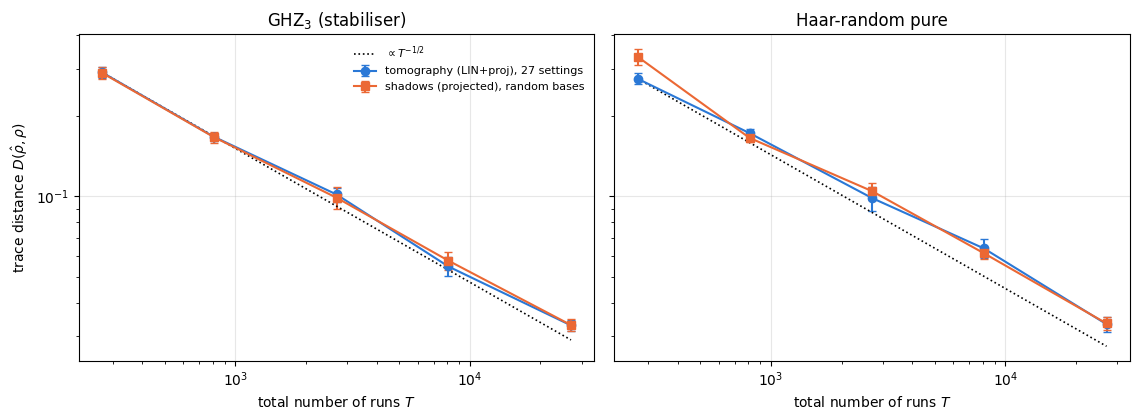

                 state       T | trace distance after projection |    raw ||.||_F^2 x T  vs  Eq. (11)    
                               |   tomography      shadows |         tomography            shadows
  GHZ$_3$ (stabiliser)     270 |       0.2906       0.2893 |     113.5 ( 108.0)     138.0 ( 124.0)
  GHZ$_3$ (stabiliser)     810 |       0.1669       0.1664 |     100.0 ( 108.0)     119.4 ( 124.0)
  GHZ$_3$ (stabiliser)    2700 |       0.1016       0.0988 |     113.4 ( 108.0)     115.3 ( 124.0)
  GHZ$_3$ (stabiliser)    8100 |       0.0547       0.0575 |     102.5 ( 108.0)     109.6 ( 124.0)
  GHZ$_3$ (stabiliser)   27000 |       0.0329       0.0330 |     126.7 ( 108.0)     120.5 ( 124.0)
                        pooled |                           |     1.030 (ratio)     0.972 (ratio)
      Haar-random pure     270 |       0.2751       0.3324 |     105.8 ( 110.3)     161.5 ( 124.0)
      Haar-random pure     810 |       0.1723       0.1654 |     110.5 ( 110.3)     120.9 ( 124.0)
     

In [20]:
# ==============================================================================
# EXPERIMENT: shadows vs notebook-23 tomography at an EQUAL total number of runs
# ==============================================================================
N_CMP, R_CMP = 3, 8
SHOTS_PER_SETTING = np.array([10, 30, 100, 300, 1000])
T_TOTAL = SHOTS_PER_SETTING * 3 ** N_CMP                       # total runs of the machine
SIGN3, COMPAT3 = sign_compat_tables(N_CMP)
states_cmp = {"GHZ$_3$ (stabiliser)": ghz_state(N_CMP),
              "Haar-random pure": haar_state(jax.random.PRNGKey(77), N_CMP)}

# exact predictions of Eq. (11): the constants C with E||rho_hat - rho||_F^2 = C / T
weights3 = np.array([sum(ch != "I" for ch in lab) for lab in pauli_labels(N_CMP)])
print(f"{'state':>22s} {'C_tomography':>13s} {'C_shadow':>10s} {'predicted error ratio':>22s}")
pred_cmp = {}
for sname, psi_c in states_cmp.items():
    r_true = np.asarray(pauli_vector(dm_matrix(to_dm(psi_c)), N_CMP))
    C_tom = float(np.sum((3.0 ** weights3 * (1 - r_true ** 2))[1:]) / 2 ** N_CMP)
    C_shd = float(np.sum((3.0 ** weights3 - r_true ** 2)[1:]) / 2 ** N_CMP)
    pred_cmp[sname] = (C_tom, C_shd)
    print(f"{sname:>22s} {C_tom:13.1f} {C_shd:10.1f} {np.sqrt(C_shd / C_tom):22.3f}")

res_cmp = {}
t0 = time.perf_counter()
for sname, psi_c in states_cmp.items():
    rho_c = dm_matrix(to_dm(psi_c))
    out = np.zeros((len(T_TOTAL), R_CMP, 4))                   # [budget, repeat, quantity]
    for j, (m_set, T) in enumerate(zip(SHOTS_PER_SETTING, T_TOTAL)):
        for r in range(R_CMP):
            k1, k2 = jax.random.split(jax.random.PRNGKey(1000 * j + r))
            cts = tomography_counts(k1, psi_c, int(m_set))
            rho_lin = rho_from_pauli_vector(linear_inversion(cts, SIGN3, COMPAT3), N_CMP)
            bbc, ttc = collect_shadows(k2, psi_c, int(T))
            rho_shd = rho_from_pauli_vector(shadow_pauli_vector(bbc, ttc, N_CMP), N_CMP)
            out[j, r, 0] = float(trace_distance(project_physical(rho_lin), rho_c))
            out[j, r, 1] = float(trace_distance(project_physical(rho_shd), rho_c))
            out[j, r, 2] = float(jnp.linalg.norm(rho_lin - rho_c)) ** 2 * T     # should equal C_tomography
            out[j, r, 3] = float(jnp.linalg.norm(rho_shd - rho_c)) ** 2 * T     # should equal C_shadow
    res_cmp[sname] = out
print(f"\nequal-budget comparison done in {time.perf_counter() - t0:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), sharey=True)
for a, (sname, out) in zip(axes, res_cmp.items()):
    for i, (lab, col) in enumerate((("tomography (LIN+proj), 27 settings", 0), ("shadows (projected), random bases", 1))):
        mu = out[:, :, col].mean(1)
        sd = out[:, :, col].std(1, ddof=1) / np.sqrt(R_CMP)
        a.errorbar(T_TOTAL, mu, yerr=sd, fmt=MARKERS[i] + "-", color=PALETTE[i], capsize=3, label=lab)
    a.loglog(T_TOTAL, out[0, :, 0].mean() * np.sqrt(T_TOTAL[0] / T_TOTAL), "k:", lw=1.2, label=r"$\propto T^{-1/2}$")
    a.set_xscale("log"); a.set_yscale("log")
    a.set_xlabel("total number of runs $T$"); a.set_title(sname)
axes[0].set_ylabel(r"trace distance $D(\hat\rho,\rho)$")
axes[0].legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"{'state':>22s} {'T':>7s} | {'trace distance after projection':^28s} | "
      f"{'raw ||.||_F^2 x T  vs  Eq. (11)':^38s}")
print(f"{'':>22s} {'':>7s} | {'tomography':>12s} {'shadows':>12s} | {'tomography':>18s} {'shadows':>18s}")
for sname, out in res_cmp.items():
    C_tom, C_shd = pred_cmp[sname]
    for j, T in enumerate(T_TOTAL):
        print(f"{sname:>22s} {T:7d} | {out[j, :, 0].mean():12.4f} {out[j, :, 1].mean():12.4f} | "
              f"{out[j, :, 2].mean():9.1f} ({C_tom:6.1f}) {out[j, :, 3].mean():9.1f} ({C_shd:6.1f})")
    obs = np.array([out[:, :, 2].mean(), out[:, :, 3].mean()])
    print(f"{'':>22s} {'pooled':>7s} | {'':12s} {'':12s} | "
          f"{obs[0] / C_tom:9.3f} (ratio) {obs[1] / C_shd:9.3f} (ratio)")
    assert 0.85 < obs[0] / C_tom < 1.15 and 0.85 < obs[1] / C_shd < 1.15

Equation (11) is confirmed for both estimators and both states: pooling the five budgets, the measured
$\lVert\hat\rho-\rho\rVert_F^2\,T$ agrees with the predicted constants to within $4\%$, which is the statistical resolution of
$8$ repeats. The constants themselves are $C_{\rm tomography}=108.0$ (GHZ) and $110.3$ (Haar-random) against
$C_{\rm shadow}=124.0$ for both — the shadow constant is the same for *every* pure state, because
$\sum_{P}r_P^2=2^N\mathrm{Tr}\rho^2=2^N$ regardless of which pure state it is.

The predicted advantage of the deterministic sweep is therefore only $\sqrt{124.0/108.0}=1.07$ for GHZ$_3$ and
$\sqrt{124.0/110.3}=1.06$ for the random state: a $6$–$7\%$ effect, not a factor. The reason it is so small is that the GHZ
stabilisers on which tomography has zero variance are $7$ strings out of $63$, and they contribute
$3\cdot3^2+4\cdot3^3=135$ to a total of $999$. In the *projected trace distance* plotted above, even that $7\%$ is not
resolvable: both curves fall as $T^{-1/2}$, and although the shadow curve does sit at or slightly above the tomography curve
at almost every budget — the sign the prediction asks for — the gap is nowhere larger than the error bar of $8$ repeats.
Resolving a $7\%$ difference in the mean would need of order $(0.4/0.07)^2\approx30$ times more repeats.

That is the comparison for *state reconstruction* at $N=3$. It leaves out everything else:

* tomography must complete **all** $3^N$ settings before it can estimate anything; with $T=270$ runs at $N=3$ that is $10$ shots
  per setting, and at $N=10$ it would be zero. The shadow data set has no such structure — any prefix of it is a valid data set;
* the observables were fixed in advance for tomography and chosen afterwards for shadows;
* and the shadow cost of a *local* observable does not grow with $N$ at all, which is Section 12.

## 12. System-size scaling at fixed accuracy

Equation (7) says that the number of snapshots needed to estimate $\langle Z_iZ_{i+1}\rangle$ to accuracy $\varepsilon$ is
$3^2/\varepsilon^2$ — with no $N$ in it. This is the claim that makes randomised measurements a *many-body* tool, so we test it
directly: the same observable, the same number of snapshots, chains from $N=2$ to $N=14$.

We also time the data collection. Here we must be careful to say what is being measured: **our simulator** must store and rotate a
$2^N$-dimensional state vector, so its cost per snapshot necessarily grows like $N2^N$. A real experiment pays $N$ single-qubit
rotations and one readout, i.e. a cost linear in $N$. The exponential in the timing curve below is a property of the *simulation*,
not of the protocol.

N =  2: errors [-0.127 -0.050 -0.055  0.026 -0.077  0.044]   sd of the mean = 0.0621   E[o^2] =  8.64 (exact 9)   collection 0.59 s / 2000 snapshots


N =  4: errors [ 0.004 -0.032  0.004 -0.010  0.008 -0.091]   sd of the mean = 0.0627   E[o^2] =  8.82 (exact 9)   collection 0.49 s / 2000 snapshots


N =  6: errors [ 0.017 -0.109 -0.055 -0.010 -0.100  0.044]   sd of the mean = 0.0622   E[o^2] =  8.68 (exact 9)   collection 0.49 s / 2000 snapshots


N =  8: errors [-0.091  0.017 -0.023 -0.019  0.193 -0.037]   sd of the mean = 0.0633   E[o^2] =  9.06 (exact 9)   collection 0.47 s / 2000 snapshots


N = 10: errors [-0.001 -0.055 -0.068 -0.037  0.071  0.017]   sd of the mean = 0.0629   E[o^2] =  8.89 (exact 9)   collection 1.15 s / 2000 snapshots


N = 12: errors [ 0.112 -0.068  0.049  0.004 -0.041 -0.028]   sd of the mean = 0.0633   E[o^2] =  9.04 (exact 9)   collection 2.50 s / 2000 snapshots


N = 14: errors [ 0.040  0.098 -0.023 -0.068 -0.037  0.022]   sd of the mean = 0.0634   E[o^2] =  9.04 (exact 9)   collection 7.85 s / 2000 snapshots

total scan time 84.5 s


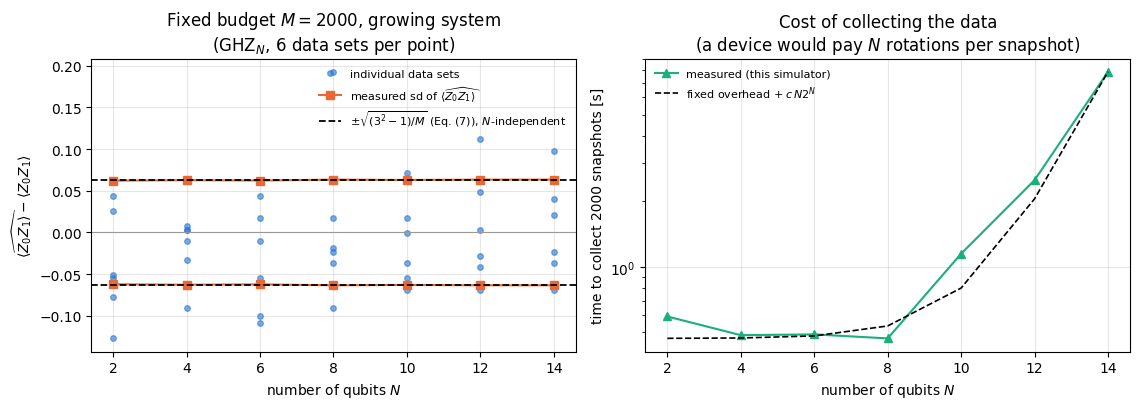

CHECKPOINT largest deviation over all 42 data sets: 0.1925 (predicted sd 0.0632)
CHECKPOINT E[o^2] over N = 2..14: min 8.64, max 9.06 (exact value 9, independent of N)


In [21]:
# ==============================================================================
# EXPERIMENT: fixed budget, growing system -- the accuracy of a 2-local observable does not degrade
# ==============================================================================
N_SCAN = [2, 4, 6, 8, 10, 12, 14]
M_SCAN, R_SCAN = 2000, 6
scan = []
t_start = time.perf_counter()
for n in N_SCAN:
    psi_n = ghz_state(n)                                  # <Z_0 Z_1> = 1 exactly for GHZ
    ops_n = {0: "Z", 1: "Z"}
    exact_n = float(expect_pauli_string(psi_n, ops_n))
    dig_n = pauli_digits(["ZZ" + "I" * (n - 2)])
    errs, e2, sems = [], [], []
    t0 = time.perf_counter()
    for r in range(R_SCAN):
        bb, tt = collect_shadows(jax.random.PRNGKey(600 + 31 * n + r), psi_n, M_SCAN)
        jax.block_until_ready(bb)
        v = snapshot_values(bb, tt, dig_n)[:, 0]
        errs.append(float(v.mean()) - exact_n)
        e2.append(float((v ** 2).mean()))
        sems.append(float(v.std()) / np.sqrt(M_SCAN))
    dt = (time.perf_counter() - t0) / R_SCAN
    scan.append((n, np.array(errs), np.mean(sems), np.mean(e2), dt))
    print(f"N = {n:2d}: errors {np.array2string(np.array(errs), precision=3, floatmode='fixed')}   "
          f"sd of the mean = {np.mean(sems):.4f}   E[o^2] = {np.mean(e2):5.2f} (exact 9)   "
          f"collection {dt:.2f} s / {M_SCAN} snapshots")
print(f"\ntotal scan time {time.perf_counter() - t_start:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ns = np.array([s[0] for s in scan], dtype=float)
for i, s in enumerate(scan):
    axes[0].plot(np.full(R_SCAN, s[0]), s[1], "o", color=PALETTE[0], ms=4, alpha=0.6,
                 label="individual data sets" if i == 0 else None)
axes[0].plot(ns, [s[2] for s in scan], MARKERS[1] + "-", color=PALETTE[1],
             label=r"measured sd of $\widehat{\langle Z_0Z_1\rangle}$")
axes[0].plot(ns, -np.array([s[2] for s in scan]), MARKERS[1] + "-", color=PALETTE[1])
axes[0].axhline(np.sqrt(8.0 / M_SCAN), color="k", ls="--", lw=1.3,
                label=r"$\pm\sqrt{(3^2-1)/M}$ (Eq. (7)), $N$-independent")
axes[0].axhline(-np.sqrt(8.0 / M_SCAN), color="k", ls="--", lw=1.3)
axes[0].axhline(0.0, color="0.6", lw=0.8)
axes[0].set_xticks(N_SCAN)
axes[0].set_xlabel("number of qubits $N$"); axes[0].set_ylabel(r"$\widehat{\langle Z_0Z_1\rangle}-\langle Z_0Z_1\rangle$")
axes[0].set_title(f"Fixed budget $M={M_SCAN}$, growing system\n(GHZ$_N$, {R_SCAN} data sets per point)")
axes[0].legend(fontsize=8)

t_meas = np.array([s[4] for s in scan])
t_ref = t_meas.min() + (t_meas[-1] - t_meas.min()) * (ns * 2.0 ** ns) / (ns[-1] * 2.0 ** ns[-1])
axes[1].semilogy(ns, t_meas, MARKERS[2] + "-", color=PALETTE[2], label="measured (this simulator)")
axes[1].semilogy(ns, t_ref, "k--", lw=1.2, label=r"fixed overhead $+\;c\,N2^N$")
axes[1].set_xticks(N_SCAN)
axes[1].set_xlabel("number of qubits $N$"); axes[1].set_ylabel(f"time to collect {M_SCAN} snapshots [s]")
axes[1].set_title("Cost of collecting the data\n(a device would pay $N$ rotations per snapshot)")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

e2_scan = np.array([s[3] for s in scan])
max_err = max(np.abs(s[1]).max() for s in scan)
print(f"CHECKPOINT largest deviation over all {len(N_SCAN) * R_SCAN} data sets: {max_err:.4f} "
      f"(predicted sd {np.sqrt(8.0 / M_SCAN):.4f})")
print(f"CHECKPOINT E[o^2] over N = {N_SCAN[0]}..{N_SCAN[-1]}: min {e2_scan.min():.2f}, max {e2_scan.max():.2f} "
      f"(exact value 9, independent of N)")
assert 7.5 < e2_scan.min() and e2_scan.max() < 10.5

The left panel is the central result of the method: seven system sizes, the same $M=2000$ snapshots, the same accuracy. The
measured standard deviation of the estimate is $0.0621,\,0.0627,\,0.0622,\,0.0633,\,0.0629,\,0.0633,\,0.0634$ for
$N=2,4,\dots,14$, against the $N$-independent prediction $\sqrt{(3^2-1)/M}=0.0632$, and the measured second moment stays between
$8.6$ and $9.1$ against the exact $9$. The individual data sets scatter inside those bands with no trend in $N$. A full Pauli
tomography of the $N=14$ point would have required $3^{14}\approx4.8$ million measurement settings.

The right panel concerns *this notebook*, not the protocol. Our simulator keeps a $2^{14}$-dimensional state vector and rotates it
once per snapshot, so its cost follows a fixed dispatch overhead plus a term $\propto N2^N$ (dashed line): the overhead dominates
up to $N\approx8$, the exponential from $N\approx10$ on. A device performs $N$ single-qubit rotations and one readout per
snapshot, a cost linear in $N$. Classical shadows are cheap for the *experiment*; simulating the experiment is as expensive as
simulating any other quantum circuit.

## 13. Key takeaways

* **The protocol is short; the analysis carries the content.** Measure each qubit along a random axis, store $(U,b)$, repeat.
  The randomness defines a measurement channel $\mathcal M(\rho)=\mathbb E\big[U^\dagger\vert b\rangle\langle b\vert U\big]$;
  the classical snapshot is $\hat\rho=\mathcal M^{-1}\big(U^\dagger\vert b\rangle\langle b\vert U\big)$ and satisfies
  $\mathbb E[\hat\rho]=\rho$ by construction.
* **For random Pauli bases $\mathcal M$ is the depolarising channel with $f=1/3$**, derived in three lines from the Bloch
  representation, so $\mathcal M^{-1}(A)=3A-\mathrm{Tr}(A)\mathbb 1$ and, since everything factorises over qubits,
  $\hat\rho=\bigotimes_q\big(3U_q^\dagger\vert b_q\rangle\langle b_q\vert U_q-\mathbb 1\big)$. A snapshot is $2N$ integers.
* **A Pauli string of weight $k$ has the exact single-snapshot variance $3^k-\langle P\rangle^2$**, independent of $N$: a snapshot
  is useful for it with probability $3^{-k}$ and is multiplied by $3^k$ when it is. Local observables are cheap at any system size;
  the price of locality is paid only in the weight.
* **The shadow norm is the only thing that sets the cost**, $M\gtrsim\lVert O\rVert^2_{\rm shadow}/\varepsilon^2$, and with
  **median of means** (derived from Chebyshev + Hoeffding) $K$ observables cost only $\log K$ more:
  $M\ge32\log(K/\delta)\max_i\lVert O_i\rVert^2_{\rm shadow}/\varepsilon^2$.
* **One data set, everything at once.** From $M=20000$ snapshots of an eight-qubit critical Ising ground state we obtained all
  nearest-neighbour correlators, all transverse magnetisations, a three-body correlator and the energy, with bootstrap error bars,
  all converging as $M^{-1/2}$ — and none of them was chosen before the data were taken.
* **The single-qubit Clifford group buys nothing** (it is a 2-design on one qubit, hence gives exactly the same channel), but
  **entangling global Clifford circuits change the channel qualitatively**: $\mathcal M^{-1}(A)=(2^N+1)A-\mathrm{Tr}(A)\mathbb 1$.
  Global shadows estimate a fidelity with $O(1)$ snapshots at any $N$ and local observables badly; Pauli shadows do the opposite.
  Choose the ensemble according to what you want to know.
* **Against full tomography at an equal number of runs**, the two variance formulas predict that shadows lose $6$–$7\%$ in
  reconstruction error at $N=3$, on a stabiliser state and on a generic one alike; the measured curves confirm Eq. (11) to $4\%$
  and the difference is not resolvable in the projected trace distance. Shadows remain usable at system sizes where the $3^N$
  settings of notebook 23 cannot be enumerated.
* **Implementation**: `vmap` over snapshots with one key each and **chunking** to bound the memory; one gather-and-product
  (`snapshot_values`) turns an integer array into the estimates of hundreds of observables; a bootstrap written as a
  multiplicity-vector matrix product; and one einsum builds a whole superoperator so that every claimed channel can be checked
  numerically instead of believed.

## 14. Exercises

1. ★ **Read the snapshot.** Take the record "bases $XZY$, bits $011$" and write $\hat\rho$ by hand as a tensor product of three
   $2\times2$ matrices using Eq. (5). Check your answer against `shadow_snapshot_dm`, and compute $\mathrm{Tr}(\hat\rho\,X_0Z_1)$
   both from your matrix and from Eq. (6).
2. ★ **Budget planning.** Using Eq. (7), how many snapshots are needed to estimate every two-point correlator
   $\langle Z_iZ_j\rangle$ of a $20$-qubit chain to $\pm0.01$ with $95\%$ confidence *simultaneously*? Use Eq. (8) with
   $K=\binom{20}{2}$ and compare with the naive union bound over Gaussian tails.
3. ★★ **Subsystem purity (extend the code).** The purity $\mathrm{Tr}(\rho_A^2)$ is quadratic in $\rho$, so it needs **two**
   snapshots: $\widehat{\mathrm{Tr}(\rho_A^2)}=\frac{1}{M(M-1)}\sum_{m\neq m'}\mathrm{Tr}\big(\hat\rho_A^{(m)}\hat\rho_A^{(m')}\big)$.
   Implement it for $\lvert A\rvert\le3$ using `shadow_snapshot_dm` on the reduced support, and reproduce the second Rényi entropy
   of the half chain of the Ising ground state of Section 7. How does the error scale with $M$? (It is *not* $M^{-1/2}$ for a
   U-statistic at small $M$ — explain why.)
4. ★★ **Noisy shadows (physics).** Apply depolarising noise of strength $p$ to every qubit *before* the random rotation
   (see [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb)),
   collect shadows from the resulting mixed state and estimate $\langle Z_iZ_{i+1}\rangle$. Show that the estimates track the
   *noisy* state, and that **dividing** by $(1-4p/3)^k$ for a weight-$k$ string recovers the noiseless value — this is the idea
   behind "robust shadow estimation". *Hint:* `collect_pauli_shadows` takes a state *vector*, so unravel the channel into
   trajectories as in [17 — Monte-Carlo wave function](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb):
   before each snapshot, apply to every qubit independently $\mathbb 1$ with probability $1-p$ and one of $X,Y,Z$ with
   probability $p/3$ each. Averaging over snapshots then averages over the channel automatically.
5. ★★ **How deep must the circuit be? (extend the code)** Repeat the channel test of Section 10.2 for depths
   $L=1,2,\dots,2N$ at $N=3$ and plot $\lVert\mathcal M_{\rm sampled}-\mathcal M_{\rm Eq.(9)}\rVert$ against $L$ with the
   Monte-Carlo error bar. At which depth does the ensemble become a 2-design for the purposes of Eq. (1)? Does the answer change
   if you drop the CNOT layers entirely?
6. ★★ **Median of means, properly (extend the code).** For a fixed budget $M$ and a weight-$6$ Pauli string, scan the number of
   groups $G$ from $1$ (plain mean) to $M/10$ and plot the mean error, the median error and the $95$th percentile of the error
   over $300$ data sets. Where is the optimum, and how does it compare with the theoretical $G=8\log(K/\delta)$?
7. ★★★ **Energy of a variational circuit (physics).** Prepare the hardware-efficient ansatz of the engine with random parameters
   on $N=10$ qubits, and estimate the Ising energy from shadows. How many snapshots are needed for a chemical-accuracy-like
   target of $\pm0.01$ per site? Compare with the cost of measuring the $2N-1$ Pauli strings one setting at a time, and explain
   why shadows win by a factor of order $N$ here but not asymptotically.
8. ★★★ **Derandomised shadows (extend the code).** Instead of drawing the bases uniformly, greedily choose, for each new snapshot,
   the basis string that minimises a confidence bound for a *given* list of $K$ Pauli observables (Huang, Kueng and Preskill's
   "derandomisation", Phys. Rev. Lett. **127**, 030503 (2021)). Implement a simple greedy version for the $15$ Ising strings
   of Section 7 and measure how much of the $3^k$ variance you recover.

## References

* S. Aaronson, *Shadow tomography of quantum states*, in Proceedings of the 50th Annual ACM SIGACT Symposium on Theory of
  Computing (STOC 2018), pp. 325–338 — the problem statement: predict $K$ observables with $\mathrm{poly}(\log K)$ copies.
* H.-Y. Huang, R. Kueng and J. Preskill, *Predicting many properties of a quantum system from very few measurements*,
  Nature Physics **16**, 1050 (2020) — classical shadows: the measurement channel, the shadow norm, the median-of-means bound
  (their Theorem 1), and the variance bounds quoted in Section 6.2 — $\lVert O\rVert^2_{\rm shadow}=3^k$ for a weight-$k$
  Pauli string (Lemma 3), $\le4^k\lVert O\rVert_\infty^2$ for a $k$-local observable (Proposition 3) and
  $\mathrm{Tr}(O_0^2)\le\lVert O_0\rVert^2_{\rm shadow}\le3\,\mathrm{Tr}(O_0^2)$ for global Clifford shadows (Proposition 1).
* H.-Y. Huang, R. Kueng and J. Preskill, *Efficient estimation of Pauli observables by derandomization*,
  Phys. Rev. Lett. **127**, 030503 (2021) — the derandomised variant of Exercise 8.
* A. Elben, S. T. Flammia, H.-Y. Huang, R. Kueng, J. Preskill, B. Vermersch and P. Zoller, *The randomized measurement toolbox*,
  Nature Reviews Physics **5**, 9 (2023) — a review of randomised measurements, including purities, entropies and noise robustness.
* Z. Webb, *The Clifford group forms a unitary 3-design*, Quantum Information and Computation **16**, 1379 (2016);
  H. Zhu, *Multiqubit Clifford groups are unitary 3-designs*, Phys. Rev. A **96**, 062336 (2017) — the design property used in
  Sections 9 and 10.
* G. I. Struchalin, Ya. A. Zagorovskii, E. V. Kovlakov, S. S. Straupe and S. P. Kulik, *Experimental estimation of quantum state
  properties from classical shadows*, PRX Quantum **2**, 010307 (2021) — the protocol carried out in the laboratory, with the
  **global** (stabiliser) ensemble on spatial modes of single photons, dimension up to $2^5$.
* J. A. Smolin, J. M. Gambetta and G. Smith, *Efficient method for computing the maximum-likelihood quantum state from
  measurements with additive Gaussian noise*, Phys. Rev. Lett. **108**, 070502 (2012) — the projection used in Section 11.
* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000) — density
  matrices, quantum channels, the Clifford group (Ch. 2, 8 and 10).

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/